### 1. 지도 데이터 크롤링

#### 청주

In [1]:
import requests
import pandas as pd
import time

# 1. 카카오 API 호출

def fetch_kakao_category(keyword, lat, lon, rest_key, max_pages=45):
    url = "https://dapi.kakao.com/v2/local/search/category.json"
    headers = {"Authorization": f"KakaoAK {rest_key}"}

    results = []

    for page in range(1, max_pages + 1):
        params = {
            "category_group_code": "OL7",  # 주유소
            "x": lon,
            "y": lat,
            "radius": 20000,  # 청주 전역 커버
            "page": page,
            "size": 15
        }

        res = requests.get(url, headers=headers, params=params)
        data = res.json()

        # 결과 없음 → 종료
        if "documents" not in data or len(data["documents"]) == 0:
            print(f"[INFO] {keyword} 페이지 {page} → 더 이상 데이터 없음 (종료)")
            break

        print(f"[INFO] {keyword} 페이지 {page} 수집 완료")
        results.extend(data["documents"])

        time.sleep(0.2)  # rate-limit 방지

    return results

In [3]:
# 2. 좌표 기반 중복 제거
def drop_duplicates_by_xy(df):
    before = len(df)
    df = df.drop_duplicates(subset=["x", "y"])
    after = len(df)
    print(f"[INFO] 중복 제거: {before} → {after}개")
    return df

In [4]:
# 3. 전체 파이프라인 실행

def run_cheongju_pipeline(rest_key):
    # 청주 4개 구 중심점
    regions = {
        "상당구": (36.6368, 127.5110),
        "서원구": (36.6245, 127.4692),
        "흥덕구": (36.6421, 127.4250),
        "청원구": (36.6746, 127.4889),
        "남부 근교": (36.5869, 127.4686),
        "북부 근교": (36.7195, 127.4485),
        "동부 근교": (36.5808, 127.5791),
        "서부 근교": (36.6236, 127.3736),
        "오송 근교": (36.6238, 127.3378)
    }

    all_results = []

    for region, (lat, lon) in regions.items():
        print(f"\n==============================")
        print(f"[INFO] {region} (lat={lat}, lon={lon}) 검색 시작")
        print("==============================")

        res = fetch_kakao_category(region, lat, lon, rest_key)
        all_results.extend(res)

    print(f"\n[INFO] 총 수집된 데이터(중복 포함): {len(all_results)}개")

    # DataFrame 변환
    df = pd.DataFrame(all_results)

    # 좌표 기반 중복 제거 (소수점 5자리 반올림 후)
    df["x_round"] = df["x"].astype(float).round(5)
    df["y_round"] = df["y"].astype(float).round(5)
    before = len(df)
    df = df.drop_duplicates(subset=["x_round", "y_round"]).reset_index(drop=True)
    after = len(df)
    print(f"[INFO] 중복 제거: {before} → {after}개")

    return df

In [5]:
# REST KEY = "네 카카오 REST API KEY"
df = run_cheongju_pipeline(rest_key="MY_API_KEY")
df


[INFO] 상당구 (lat=36.6368, lon=127.511) 검색 시작
[INFO] 상당구 페이지 1 수집 완료
[INFO] 상당구 페이지 2 수집 완료
[INFO] 상당구 페이지 3 수집 완료
[INFO] 상당구 페이지 4 수집 완료
[INFO] 상당구 페이지 5 수집 완료
[INFO] 상당구 페이지 6 수집 완료
[INFO] 상당구 페이지 7 수집 완료
[INFO] 상당구 페이지 8 수집 완료
[INFO] 상당구 페이지 9 수집 완료
[INFO] 상당구 페이지 10 수집 완료
[INFO] 상당구 페이지 11 수집 완료
[INFO] 상당구 페이지 12 수집 완료
[INFO] 상당구 페이지 13 수집 완료
[INFO] 상당구 페이지 14 수집 완료
[INFO] 상당구 페이지 15 수집 완료
[INFO] 상당구 페이지 16 수집 완료
[INFO] 상당구 페이지 17 수집 완료
[INFO] 상당구 페이지 18 수집 완료
[INFO] 상당구 페이지 19 수집 완료
[INFO] 상당구 페이지 20 수집 완료
[INFO] 상당구 페이지 21 수집 완료
[INFO] 상당구 페이지 22 수집 완료
[INFO] 상당구 페이지 23 수집 완료
[INFO] 상당구 페이지 24 수집 완료
[INFO] 상당구 페이지 25 수집 완료
[INFO] 상당구 페이지 26 수집 완료
[INFO] 상당구 페이지 27 수집 완료
[INFO] 상당구 페이지 28 수집 완료
[INFO] 상당구 페이지 29 수집 완료
[INFO] 상당구 페이지 30 수집 완료
[INFO] 상당구 페이지 31 수집 완료
[INFO] 상당구 페이지 32 수집 완료
[INFO] 상당구 페이지 33 수집 완료
[INFO] 상당구 페이지 34 수집 완료
[INFO] 상당구 페이지 35 수집 완료
[INFO] 상당구 페이지 36 수집 완료
[INFO] 상당구 페이지 37 수집 완료
[INFO] 상당구 페이지 38 수집 완료
[INFO] 상당구 페이지 39 수집 완료
[INFO] 상당구 페이지 40 수집 완료
[INF

,address_name,category_group_code,category_group_name,category_name,distance,id,phone,place_name,place_url,road_address_name,x,y,x_round,y_round
0,충북 청주시 상당구 용담동 434,OL7,"주유소,충전소","교통,수송 > 자동차 > 주유,가스 > 주유소 > SK주유소",118,19208913,043-287-5149,골든벨주유소,http://place.map.kakao.com/19208913,충북 청주시 상당구 산성로 183,127.5100638887938,36.63755443274016,127.51006,36.63755
1,충북 청주시 상당구 대성동 1-9,OL7,"주유소,충전소","교통,수송 > 자동차 > 주유,가스 > 주유소 > HD현대오일뱅크주유소",917,10235802,043-222-0999,대성주유소,http://place.map.kakao.com/10235802,충북 청주시 상당구 용담로 101,127.501637560356,36.6334233971669,127.50164,36.63342
2,충북 청주시 상당구 용정동 403,OL7,"주유소,충전소","교통,수송 > 자동차 > 주유,가스 > LPG충전소 > SK LPG충전소",1241,21850036,043-283-2111,동부LPG충전소,http://place.map.kakao.com/21850036,충북 청주시 상당구 이정골로 9,127.52034381260506,36.62852303313543,127.52034,36.62852
3,충북 청주시 상당구 용정동 263-2,OL7,"주유소,충전소","교통,수송 > 자동차 > 주유,가스 > 주유소 > SK주유소",1416,11572523,043-287-5151,양궁장주유소,http://place.map.kakao.com/11572523,충북 청주시 상당구 1순환로 1500,127.520168513048,36.6263944327129,127.52017,36.62639
4,충북 청주시 상당구 문화동 15-49,OL7,"주유소,충전소","교통,수송 > 자동차 > 주유,가스 > 주유소 > HD현대오일뱅크주유소",1661,7875206,043-225-5189,황금주유소,http://place.map.kakao.com/7875206,충북 청주시 상당구 대성로 92,127.492872324286,36.633517653407,127.49287,36.63352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,세종특별자치시 조치원읍 번암리 133,OL7,"주유소,충전소","교통,수송 > 자동차 > 주유,가스 > 주유소 > GS칼텍스",5916,1915036608,044-863-3885,명성주유소,http://place.map.kakao.com/1915036608,세종특별자치시 조치원읍 세종로 2210,127.292932635646,36.5846360472926,127.29293,36.58464
213,세종특별자치시 조치원읍 번암리 189-4,OL7,"주유소,충전소","교통,수송 > 자동차 > 주유,가스 > 주유소 > SK주유소",6272,8542074,044-866-5151,한유에너지 중부주유소,http://place.map.kakao.com/8542074,세종특별자치시 조치원읍 세종로 2167,127.29271373375296,36.58052106794425,127.29271,36.58052
214,세종특별자치시 연서면 월하리 649-8,OL7,"주유소,충전소","교통,수송 > 자동차 > 주유,가스 > 주유소 > HD현대오일뱅크주유소",6523,10051548,044-865-5724,HD현대오일뱅크직영 대일주유소,http://place.map.kakao.com/10051548,세종특별자치시 연서면 세종로 2137,127.29221343389803,36.57792339937415,127.29221,36.57792
215,세종특별자치시 조치원읍 번암리 189-3,OL7,"주유소,충전소","교통,수송 > 자동차 > 주유,가스 > LPG충전소 > SK LPG충전소",6250,17821853,041-866-5151,한유에너지 중부충전소,http://place.map.kakao.com/17821853,세종특별자치시 조치원읍 세종로 2167,127.29274256167209,36.580757997666744,127.29274,36.58076


In [6]:
df['x'] = df['x'].astype(float)
df['y'] = df['y'].astype(float)

In [7]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km
    dLat = np.radians(lat2 - lat1)
    dLon = np.radians(lon2 - lon1)
    a = (np.sin(dLat/2)**2 + 
         np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * 
         np.sin(dLon/2)**2)
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# 사용자 기준 위치
origin_lat = 36.622146
origin_lon = 127.318527

df["distance_km"] = df.apply(
    lambda row: haversine(origin_lat, origin_lon, row["y"], row["x"]),
    axis=1
)

In [8]:
# CSV 저장 
from datetime import datetime

# 1. 오늘 날짜 가져오기
today = datetime.now().strftime("%Y%m%d")
# 2. 파일명 설정
file_name = f"cheongju_gas_stations_filtered_{today}.csv"
# 3. CSV 저장
df.to_csv(file_name, index=False, encoding="utf-8-sig")

print(f"[완료] {file_name} 저장!")

[완료] cheongju_gas_stations_filtered_20260120.csv 저장!


#### 대전

In [9]:
# 1. 카카오 API 호출

def fetch_kakao_category(keyword, lat, lon, rest_key, max_pages=45):
    url = "https://dapi.kakao.com/v2/local/search/category.json"
    headers = {"Authorization": f"KakaoAK {rest_key}"}

    results = []

    for page in range(1, max_pages + 1):
        params = {
            "category_group_code": "OL7",  # 주유소
            "x": lon,
            "y": lat,
            "radius": 12000,  # 대전 전역
            "page": page,
            "size": 15
        }

        res = requests.get(url, headers=headers, params=params)
        data = res.json()

        # 결과 없음 → 종료
        if "documents" not in data or len(data["documents"]) == 0:
            print(f"[INFO] {keyword} 페이지 {page} → 더 이상 데이터 없음 (종료)")
            break

        print(f"[INFO] {keyword} 페이지 {page} 수집 완료")
        results.extend(data["documents"])

        time.sleep(0.2)  # rate-limit 방지

    return results

In [10]:
# 2. 좌표 기반 중복 제거
def drop_duplicates_by_xy(df):
    before = len(df)
    df = df.drop_duplicates(subset=["x", "y"])
    after = len(df)
    print(f"[INFO] 중복 제거: {before} → {after}개")
    return df

In [11]:
# 3. 전체 파이프라인 실행

def run_cheongju_pipeline(rest_key):
    # 대전 지역 구 중심점
    regions = {
        "대덕구": (36.4145, 127.4390),
        "유성구": (36.3622, 127.3560),
        "서구":   (36.3554, 127.3838),
        "중구":   (36.3256, 127.4213),
        "동구":   (36.3116, 127.4549),
    
        # 외곽 보정
        "대전 북서": (36.3950, 127.3150),
        "대전 남서": (36.3050, 127.3350),
        "대전 동부": (36.3350, 127.5000),
        "대전 북동": (36.3739, 127.4112)
    }

    all_results = []

    for region, (lat, lon) in regions.items():
        print(f"\n==============================")
        print(f"[INFO] {region} (lat={lat}, lon={lon}) 검색 시작")
        print("==============================")

        res = fetch_kakao_category(region, lat, lon, rest_key)
        all_results.extend(res)

    print(f"\n[INFO] 총 수집된 데이터(중복 포함): {len(all_results)}개")

    # DataFrame 변환
    df = pd.DataFrame(all_results)

    # 좌표 기반 중복 제거 (소수점 5자리 반올림 후)
    df["x_round"] = df["x"].astype(float).round(5)
    df["y_round"] = df["y"].astype(float).round(5)
    before = len(df)
    df = df.drop_duplicates(subset=["x_round", "y_round"]).reset_index(drop=True)
    after = len(df)
    print(f"[INFO] 중복 제거: {before} → {after}개")

    return df

In [12]:
# REST KEY = "네 카카오 REST API KEY"
df = run_cheongju_pipeline(rest_key="MY_API_KEY")
df


[INFO] 대덕구 (lat=36.4145, lon=127.439) 검색 시작
[INFO] 대덕구 페이지 1 수집 완료
[INFO] 대덕구 페이지 2 수집 완료
[INFO] 대덕구 페이지 3 수집 완료
[INFO] 대덕구 페이지 4 수집 완료
[INFO] 대덕구 페이지 5 수집 완료
[INFO] 대덕구 페이지 6 수집 완료
[INFO] 대덕구 페이지 7 수집 완료
[INFO] 대덕구 페이지 8 수집 완료
[INFO] 대덕구 페이지 9 수집 완료
[INFO] 대덕구 페이지 10 수집 완료
[INFO] 대덕구 페이지 11 수집 완료
[INFO] 대덕구 페이지 12 수집 완료
[INFO] 대덕구 페이지 13 수집 완료
[INFO] 대덕구 페이지 14 수집 완료
[INFO] 대덕구 페이지 15 수집 완료
[INFO] 대덕구 페이지 16 수집 완료
[INFO] 대덕구 페이지 17 수집 완료
[INFO] 대덕구 페이지 18 수집 완료
[INFO] 대덕구 페이지 19 수집 완료
[INFO] 대덕구 페이지 20 수집 완료
[INFO] 대덕구 페이지 21 수집 완료
[INFO] 대덕구 페이지 22 수집 완료
[INFO] 대덕구 페이지 23 수집 완료
[INFO] 대덕구 페이지 24 수집 완료
[INFO] 대덕구 페이지 25 수집 완료
[INFO] 대덕구 페이지 26 수집 완료
[INFO] 대덕구 페이지 27 수집 완료
[INFO] 대덕구 페이지 28 수집 완료
[INFO] 대덕구 페이지 29 수집 완료
[INFO] 대덕구 페이지 30 수집 완료
[INFO] 대덕구 페이지 31 수집 완료
[INFO] 대덕구 페이지 32 수집 완료
[INFO] 대덕구 페이지 33 수집 완료
[INFO] 대덕구 페이지 34 수집 완료
[INFO] 대덕구 페이지 35 수집 완료
[INFO] 대덕구 페이지 36 수집 완료
[INFO] 대덕구 페이지 37 수집 완료
[INFO] 대덕구 페이지 38 수집 완료
[INFO] 대덕구 페이지 39 수집 완료
[INFO] 대덕구 페이지 40 수집 완료
[INF

,address_name,category_group_code,category_group_name,category_name,distance,id,phone,place_name,place_url,road_address_name,x,y,x_round,y_round
0,대전 대덕구 와동 173-1,OL7,"주유소,충전소","교통,수송 > 자동차 > 주유,가스 > 주유소 > SK주유소",1317,8016235,042-721-0607,와동셀프주유소,http://place.map.kakao.com/8016235,대전 대덕구 신탄진로 386,127.42431207440721,36.41437920838946,127.42431,36.41438
1,대전 대덕구 와동 217-1,OL7,"주유소,충전소","교통,수송 > 자동차 > 주유,가스 > 주유소 > SK주유소",1376,23769506,042-621-5185,SK주홍셀프주유소,http://place.map.kakao.com/23769506,대전 대덕구 신탄진로 383,127.423674579015,36.413810133945,127.42367,36.41381
2,대전 대덕구 상서동 442-2,OL7,"주유소,충전소","교통,수송 > 자동차 > 주유,가스 > 주유소 > HD현대오일뱅크주유소",1871,19386707,042-936-9934,대덕주유소,http://place.map.kakao.com/19386707,대전 대덕구 신탄진로 470,127.41995356019622,36.421385842346034,127.41995,36.42139
3,대전 대덕구 상서동 349-12,OL7,"주유소,충전소","교통,수송 > 자동차 > 주유,가스 > LPG충전소 > SK LPG충전소",2052,9195625,042-934-1051,신탄진충전소,http://place.map.kakao.com/9195625,대전 대덕구 신탄진로 520,127.420382547143,36.4252593323055,127.42038,36.42526
4,대전 대덕구 상서동 440,OL7,"주유소,충전소","교통,수송 > 자동차 > 주유,가스 > LPG충전소 > GS칼텍스 LPG충전소",1924,8901797,042-932-6460,상서충전소,http://place.map.kakao.com/8901797,대전 대덕구 신탄진로 484,127.4198942643933,36.42238453935426,127.41989,36.42238
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224,대전 대덕구 대화동 3-1,OL7,"주유소,충전소","교통,수송 > 자동차 > 주유,가스 > LPG충전소 > E1 LPG충전소",912,8901664,042-622-7025,대전LPG충전소,http://place.map.kakao.com/8901664,대전 대덕구 대화로50번길 90,127.41910203772582,36.36871742709739,127.41910,36.36872
225,대전 대덕구 대화동 4-1,OL7,"주유소,충전소","교통,수송 > 자동차 > 주유,가스 > 주유소 > GS칼텍스",969,11952218,042-634-0225,공단주유소,http://place.map.kakao.com/11952218,대전 대덕구 대전로 1285,127.419765370598,36.3685709109808,127.41977,36.36857
226,대전 대덕구 대화동 16-140,OL7,"주유소,충전소","교통,수송 > 자동차 > 주유,가스 > LPG충전소 > E1 LPG충전소",1262,562424459,042-625-0344,알파앤에너지 대화충전소,http://place.map.kakao.com/562424459,대전 대덕구 대전로 1238,127.418837900373,36.3643422657008,127.41884,36.36434
227,대전 대덕구 중리동 410-4,OL7,"주유소,충전소","교통,수송 > 자동차 > 주유,가스 > 주유소 > S-OIL",2079,9930035,042-633-7186,대전이데아주유소,http://place.map.kakao.com/9930035,대전 대덕구 한밭대로 1145,127.425624738817,36.3592356726216,127.42562,36.35924


In [13]:
df['x'] = df['x'].astype(float)
df['y'] = df['y'].astype(float)

In [14]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km
    dLat = np.radians(lat2 - lat1)
    dLon = np.radians(lon2 - lon1)
    a = (np.sin(dLat/2)**2 + 
         np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * 
         np.sin(dLon/2)**2)
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# 사용자 기준 위치
origin_lat = 36.622146
origin_lon = 127.318527

df["distance_km"] = df.apply(
    lambda row: haversine(origin_lat, origin_lon, row["y"], row["x"]),
    axis=1
)

In [15]:
# CSV 저장 
from datetime import datetime

# 1. 오늘 날짜 가져오기
today = datetime.now().strftime("%Y%m%d")
# 2. 파일명 설정
file_name = f"daejeon_gas_stations_filtered_{today}.csv"
# 3. CSV 저장
df.to_csv(file_name, index=False, encoding="utf-8-sig")

print(f"[완료] {file_name} 저장!")

[완료] daejeon_gas_stations_filtered_20260120.csv 저장!


In [16]:
import requests
import pandas as pd
import numpy as np

# 1. 거리 계산 함수 (Haversine)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km
    dLat = np.radians(lat2 - lat1)
    dLon = np.radians(lon2 - lon1)
    a = (np.sin(dLat/2)**2 + 
         np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dLon/2)**2)
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# 2. 특정 주유소 검색 함수
def get_specific_station_to_df(station_name, api_key, origin_lat, origin_lon):
    url = "https://dapi.kakao.com/v2/local/search/keyword.json"
    headers = {"Authorization": f"KakaoAK {api_key}"}
    params = {"query": station_name}
    
    try:
        res = requests.get(url, headers=headers, params=params)
        if res.status_code == 200:
            docs = res.json().get('documents', [])
            if docs:
                target = docs[0]
                
                # 좌표 타입 변환 및 반올림 (소수점 4자리)
                target['x'] = float(target['x'])
                target['y'] = float(target['y'])
                target['x_round'] = round(target['x'], 4)
                target['y_round'] = round(target['y'], 4)
                
                # 거리 계산
                target['distance_km'] = haversine(origin_lat, origin_lon, target['y'], target['x'])
                
                return target
        return None
    except Exception as e:
        print(f"Error searching {station_name}: {e}")
        return None

# --- 실행 부분 ---

# 설정값
KAKAO_API_KEY = "MY_API_KEY"
origin_lat = 36.622146
origin_lon = 127.318527

# 누락된 주유소 리스트
missing_names = ["오일마스터 킹콩 주유소 대전지점"] 

# 결과 수집
added_stations_list = []
for name in missing_names:
    result = get_specific_station_to_df(name, KAKAO_API_KEY, origin_lat, origin_lon)
    if result:
        added_stations_list.append(result)
        print(f"✅ 수집 완료: {result['place_name']}")

# 3. 별도의 데이터프레임 df_added 생성
df_added = pd.DataFrame(added_stations_list)

# 결과 확인
print("\n📊 df_added 내용 확인:")
display(df_added)

✅ 수집 완료: S-OIL(셀프) 오일마스터대전지점킹콩주유소

📊 df_added 내용 확인:


,address_name,category_group_code,category_group_name,category_name,distance,id,phone,place_name,place_url,road_address_name,x,y,x_round,y_round,distance_km
0,대전 대덕구 읍내동 488-4,,,"교통,수송 > 자동차 > 주유,가스 > 주유소",,719626613,,S-OIL(셀프) 오일마스터대전지점킹콩주유소,http://place.map.kakao.com/719626613,대전 대덕구 아리랑로 107,127.416862,36.375304,127.4169,36.3753,28.820663


In [17]:
df_added.loc[
    df_added["place_url"] == "http://place.map.kakao.com/719626613",
    ["category_group_code", "category_group_name", "distance", "phone", "brand_raw", "place_name", "brand"]
] = ["OL7", "주유소,충전소", "28.820663", "042-627-5551", "S-OIL", "㈜오일마스터 킹콩주유소 대전지점", "S-OIL"]

In [18]:
df_added[df_added["place_url"] == "http://place.map.kakao.com/719626613"]

,address_name,category_group_code,category_group_name,category_name,distance,id,phone,place_name,place_url,road_address_name,x,y,x_round,y_round,distance_km,brand_raw,brand
0,대전 대덕구 읍내동 488-4,OL7,"주유소,충전소","교통,수송 > 자동차 > 주유,가스 > 주유소",28.820663,719626613,042-627-5551,㈜오일마스터 킹콩주유소 대전지점,http://place.map.kakao.com/719626613,대전 대덕구 아리랑로 107,127.416862,36.375304,127.4169,36.3753,28.820663,S-OIL,S-OIL


In [19]:
# 1. 기존에 저장된 CSV 파일 불러오기
file_path = 'daejeon_gas_stations_filtered_20260120.csv'

try:
    df_existing = pd.read_csv(file_path)
    print(f"📂 기존 파일 로드 완료: {len(df_existing)}개의 주유소 데이터가 있습니다.")
except FileNotFoundError:
    df_existing = pd.DataFrame()
    print("⚠️ 기존 파일을 찾을 수 없어 새로운 데이터프레임으로 시작합니다.")

# 2. df_added와 기존 데이터 합치기
# ignore_index=True를 사용해 행 번호를 재정렬합니다.
df_updated = pd.concat([df_existing, df_added], ignore_index=True)

# 3. 중복 데이터 제거 (핵심!)
# 상호명(place_name)과 주소(address_name)가 중복되는 경우, 나중에 추가된(df_added) 데이터를 남깁니다.
if not df_updated.empty:
    before_count = len(df_updated)
    df_updated = df_updated.drop_duplicates(subset=['place_name', 'address_name'], keep='last')
    after_count = len(df_updated)
    print(f"🔄 중복 제거 완료: {before_count - after_count}개의 중복 항목이 제거되었습니다.")

# 4. 최종 결과 다시 CSV로 저장 (한글 깨짐 방지 utf-8-sig)
df_updated.to_csv(file_path, index=False, encoding='utf-8-sig')

print(f"✅ 최종 통합 완료! 현재 총 {len(df_updated)}개의 주유소가 '{file_path}'에 저장되었습니다.")

# 5. 결과 확인
display(df_updated.tail())

📂 기존 파일 로드 완료: 229개의 주유소 데이터가 있습니다.
🔄 중복 제거 완료: 0개의 중복 항목이 제거되었습니다.
✅ 최종 통합 완료! 현재 총 230개의 주유소가 'daejeon_gas_stations_filtered_20260120.csv'에 저장되었습니다.


,address_name,category_group_code,category_group_name,category_name,distance,id,phone,place_name,place_url,road_address_name,x,y,x_round,y_round,distance_km,brand_raw,brand
225,대전 대덕구 대화동 4-1,OL7,"주유소,충전소","교통,수송 > 자동차 > 주유,가스 > 주유소 > GS칼텍스",969,11952218,042-634-0225,공단주유소,http://place.map.kakao.com/11952218,대전 대덕구 대전로 1285,127.419765,36.368571,127.41977,36.36857,29.612940,NaN,NaN
226,대전 대덕구 대화동 16-140,OL7,"주유소,충전소","교통,수송 > 자동차 > 주유,가스 > LPG충전소 > E1 LPG충전소",1262,562424459,042-625-0344,알파앤에너지 대화충전소,http://place.map.kakao.com/562424459,대전 대덕구 대전로 1238,127.418838,36.364342,127.41884,36.36434,30.036212,NaN,NaN
227,대전 대덕구 중리동 410-4,OL7,"주유소,충전소","교통,수송 > 자동차 > 주유,가스 > 주유소 > S-OIL",2079,9930035,042-633-7186,대전이데아주유소,http://place.map.kakao.com/9930035,대전 대덕구 한밭대로 1145,127.425625,36.359236,127.42562,36.35924,30.762090,NaN,NaN
228,대전 대덕구 중리동 252-7,OL7,"주유소,충전소","교통,수송 > 자동차 > 주유,가스 > 주유소 > SK주유소",2414,7584694,042-627-1020,중리셀프주유소,http://place.map.kakao.com/7584694,대전 대덕구 한밭대로 1186,127.430444,36.358692,127.43044,36.35869,30.956082,NaN,NaN
229,대전 대덕구 읍내동 488-4,OL7,"주유소,충전소","교통,수송 > 자동차 > 주유,가스 > 주유소",28.820663,719626613,042-627-5551,㈜오일마스터 킹콩주유소 대전지점,http://place.map.kakao.com/719626613,대전 대덕구 아리랑로 107,127.416862,36.375304,127.41690,36.37530,28.820663,S-OIL,S-OIL


### 2. 주소, 상호명 클리닝

In [20]:
import re

# 주소 클리닝 함수
def clean_address(addr: str):
    """
    주소에서 괄호 정보 제거 및 공백 정리
    """
    if pd.isna(addr):
        return None

    addr = addr.strip()

    # 괄호 및 내부 텍스트 제거
    addr = re.sub(r"\s*\(.*?\)", "", addr)

    # 공백 정리
    addr = re.sub(r"\s+", " ", addr)

    return addr.strip()

In [21]:
# category_name → 브랜드 추출

def extract_brand_from_category(cat: str):
    """
    '교통 > 자동차 > 주유소 > GS칼텍스' → 'GS칼텍스'
    """
    if pd.isna(cat):
        return None

    parts = [p.strip() for p in cat.split(">")]
    return parts[-1] if parts else None

In [22]:
# 브랜드 정규화 규칙
brand_norm_map = {
    "S오일": "S-OIL",
    "S-OIL": "S-OIL",
    "S-oil": "S-OIL",
    "에쓰오일": "S-OIL",

    "GS칼텍스": "GS칼텍스",
    "GS Caltex": "GS칼텍스",

    "SK에너지": "SK에너지",
    "SK주유소": "SK에너지",

    "HD현대오일뱅크주유소": "오일뱅크",
    "HD현대오일뱅크": "오일뱅크",
    "현대오일뱅크": "오일뱅크",
    "오일뱅크": "오일뱅크",
}

In [23]:
# 브랜드 정규화 함수
def normalize_brand(brand: str):
    """
    다양한 브랜드 표현을 하나로 통일
    """
    if pd.isna(brand):
        return None

    b = brand.strip()

    # 괄호 제거
    b = re.sub(r"\(.*?\)", "", b)

    # 특수문자 제거
    b = re.sub(r"[^0-9A-Za-z가-힣\-]", "", b)

    # 매핑 규칙 (부분 매칭)
    for key, val in brand_norm_map.items():
        if key.lower() in b.lower():
            return val

    return b

In [24]:
# 전체 전처리 파이프라인
def apply_gas_station_cleaning(input_path, output_path):
    """
    주유소 CSV 전처리 파이프라인
    """
    df = pd.read_csv(input_path)

    # 주소 정제
    if "address_name" in df.columns:
        df["address_clean"] = df["address_name"].apply(clean_address)

    # category_name → 브랜드 추출
    if "category_name" in df.columns:
        df["brand_raw"] = df["category_name"].apply(extract_brand_from_category)

    # 브랜드 통일
    df["brand"] = df["brand_raw"].apply(normalize_brand)

    # place_name 기반 보조 브랜드 정규화 (선택)
    if "place_name" in df.columns:
        df["place_name_clean"] = df["place_name"].apply(normalize_brand)

    # 저장
    df.to_csv(output_path, index=False, encoding="utf-8-sig")
    print(f"[INFO] 저장 완료 → {output_path} ({len(df)} rows)")

    return df

In [25]:
# 실행
# 대전
daejeon_df = apply_gas_station_cleaning(
    input_path="daejeon_gas_stations_filtered_20260120.csv",
    output_path="daejeon_gas_stations_cleaned_20260120.csv"
)

# 청주
cheongju_df = apply_gas_station_cleaning(
    input_path="cheongju_gas_stations_filtered_20260120.csv",
    output_path="cheongju_gas_stations_cleaned_20260120.csv"
)

[INFO] 저장 완료 → daejeon_gas_stations_cleaned_20260120.csv (230 rows)
[INFO] 저장 완료 → cheongju_gas_stations_cleaned_20260120.csv (217 rows)


In [26]:
daejeon_df[daejeon_df["place_url"] == "http://place.map.kakao.com/719626613"]

,address_name,category_group_code,category_group_name,category_name,distance,id,phone,place_name,place_url,road_address_name,x,y,x_round,y_round,distance_km,brand_raw,brand,address_clean,place_name_clean
229,대전 대덕구 읍내동 488-4,OL7,"주유소,충전소","교통,수송 > 자동차 > 주유,가스 > 주유소",28.820663,719626613,042-627-5551,㈜오일마스터 킹콩주유소 대전지점,http://place.map.kakao.com/719626613,대전 대덕구 아리랑로 107,127.416862,36.375304,127.4169,36.3753,28.820663,주유소,주유소,대전 대덕구 읍내동 488-4,오일마스터킹콩주유소대전지점


### 3. 좌표계 변환(WGS84 -> KATEC)

In [27]:
import pyproj

# 1. pyproj 변환기 준비
transformer = pyproj.Transformer.from_crs(
    "EPSG:4326", # WGS84
    "EPSG:2097", # KATEC
    always_xy=True
)

def wgs84_to_katec(lon, lat):
    try:
        x, y = transformer.transform(lon, lat)
        return x, y
    except:
        return None, None

# 2. 데이터 로드
file_names = ["daejeon_gas_stations_cleaned_20260120.csv", "cheongju_gas_stations_cleaned_20260120.csv"]
df_list = []

for file in file_names:
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

# 두 데이터를 하나로 합칩니다.
df_map_clean = pd.concat(df_list, ignore_index=True)

print(f"[INFO] {len(file_names)}개 파일 로드 및 병합 완료 (총 {len(df_map_clean)}개)")

# 3. 좌표 변환 실행
df_map_clean["katec_x"], df_map_clean["katec_y"] = zip(*df_map_clean.apply(
    lambda row: wgs84_to_katec(row["x"], row["y"]),
    axis=1
))

print("\n[INFO] 좌표 변환 완료")

# 4. 샘플 출력(WGS84 vs KATEC 비교)
print("\n[test] 변환 샘플 5개:")
print(df_map_clean[["place_name", "x", "y", "katec_x", "katec_y"]].head())

# 5. KATEC 범위 체크 (충청권: 대전·세종·청주·오송)
# x축(경도방향): 200,000 ~ 280,000 정도
# y축(위도방향): 300,000 ~ 400,000 정도
invalid = df_map_clean[
    (df_map_clean["katec_x"] < 200000) | (df_map_clean["katec_x"] > 280000) |
    (df_map_clean["katec_y"] < 300000) | (df_map_clean["katec_y"] > 420000)
]

if len(invalid) > 0:
    print(f"\n[WARNING] 범위를 벗어난 데이터 {len(invalid)}건 발견 (확인 필요):")
    print(invalid[["place_name", "x", "y", "katec_x", "katec_y"]].head())
else:
    print("\n[OK] 모든 좌표가 대전/청주 KATEC 예상 범위 안에 있음")

[INFO] 2개 파일 로드 및 병합 완료 (총 447개)

[INFO] 좌표 변환 완료

[test] 변환 샘플 5개:
  place_name           x          y        katec_x        katec_y
0    와동셀프주유소  127.424312  36.414379  238244.358654  323803.355727
1  SK주홍셀프주유소  127.423675  36.413810  238187.459155  323739.954457
2      대덕주유소  127.419954  36.421386  237850.044746  324579.155658
3     신탄진충전소  127.420383  36.425259  237886.638856  325009.159272
4      상서충전소  127.419894  36.422385  237844.243120  324689.956368

[OK] 모든 좌표가 대전/청주 KATEC 예상 범위 안에 있음


In [28]:
# 6) 기준점 검증 (집근처 좌표로 테스트)
# 실제 위경도: 36.622146, 127.318527
# 변환 예상값: 약 (x≈989000, y≈1853000) 근처
test_lon = 127.318527
test_lat = 36.622146
tx, ty = wgs84_to_katec(test_lon, test_lat)

print("\n[TEST] 기준점 변환 결과:")
print(f"WGS84  : {test_lat}, {test_lon}")
print(f"KATEC  : {tx:.2f}, {ty:.2f}")

# KATEC 기준 범위 (충북·대전·세종 기준)
if 100000 < tx < 300000 and 250000 < ty < 450000:
    print("[OK] 기준점 변환값 정상 범위 (KATEC 충북권)")
else:
    print("[ERROR] 기준점 변환값 비정상 (범위 재점검 필요)")


[TEST] 기준점 변환 결과:
WGS84  : 36.622146, 127.318527
KATEC  : 228679.80, 346822.58
[OK] 기준점 변환값 정상 범위 (KATEC 충북권)


In [29]:
df_map_clean[df_map_clean['place_name'] == '㈜오일마스터 킹콩주유소 대전지점']

,address_name,category_group_code,category_group_name,category_name,distance,id,phone,place_name,place_url,road_address_name,...,y,x_round,y_round,distance_km,brand_raw,brand,address_clean,place_name_clean,katec_x,katec_y
229,대전 대덕구 읍내동 488-4,OL7,"주유소,충전소","교통,수송 > 자동차 > 주유,가스 > 주유소",28.820663,719626613,042-627-5551,㈜오일마스터 킹콩주유소 대전지점,http://place.map.kakao.com/719626613,대전 대덕구 아리랑로 107,...,36.375304,127.4169,36.3753,28.820663,주유소,주유소,대전 대덕구 읍내동 488-4,오일마스터킹콩주유소대전지점,237594.916115,319464.31536


In [30]:
df_map_clean.loc[
    df_map_clean["place_url"] == "http://place.map.kakao.com/719626613",
    ["brand_raw", "brand"]
] = ["S-OIL", "S-OIL"]

In [38]:
# CSV 저장
df_map_clean.to_csv("map_katec_20260120.csv", index=False)
print("[완료] map_katec.csv 저장!")

[완료] map_katec.csv 저장!


### 4. Opinet 세부정보 조회(detailById.do)

#### 청주

In [32]:
from typing import List, Tuple, Dict, Any

# 1단계. 사용자 설정 변수
# 1. 오피넷에서 발급받은 실제 API 키로 변경
API_KEY = "MY_API_KEY"

# 2. 청주시 중심 좌표 (KATEC X, Y)
# API 기본 설정
BASE_URL = "https://www.opinet.co.kr/api/aroundAll.do"
RADIUS = 5000  # 반경 (최대 5000m) 
PRODCD = "B027"  # 휘발유 코드 (B027) 
SORT = 1  # 1: 가격순, 2: 거리순
OUT_FORMAT = "json" # 출력 형식

# 청주시를 커버할 주요 지점들의 KATEC 좌표 리스트
CHEONGJU_COORDS: List[Tuple[float, float]] = [
    (356466.0, 448526.0),  # 상당구
    (352721.0, 447181.0),  # 서원구 
    (348779.0, 449157.0),  # 흥덕구
    (354512.0, 452731.0),  # 청원구
    (352644.0, 443009.0),  # 남부 근교
    (350930.0, 457733.0), # 북부 근교
    (362529.0, 442284.0), # 동부 근교
    (344170.0, 447133.0), # 서부 근교
    (340974.0, 447185.0) # 오송 주변
    # 필요한 만큼 좌표를 추가해야 합니다.
]

# 2단계: API 호출 함수
def get_gas_station_data(x_coord: float, y_coord: float) -> List[Dict[str, Any]]:
    """
    특정 좌표를 기준으로 반경 내 주유소의 전체 데이터 목록을 가져옵니다.
    """
    params = {
        "code": API_KEY,
        "out": OUT_FORMAT,
        "x": x_coord,
        "y": y_coord,
        "radius": RADIUS,
        "prodcd": PRODCD,
        "sort": SORT,
    }

    try:
        response = requests.get(BASE_URL, params=params, timeout=10)
        response.raise_for_status() 

        data = response.json()
        
        result = data.get('RESULT')
        if not result:
            if data.get('errMsg'):
                 print(f"❌ API 응답 오류: {data.get('errMsg')}")
            else:
                 print("❌ API 응답에 'RESULT' 데이터가 없습니다.")
            return []
        
        # 'OIL' 키의 리스트를 그대로 반환합니다. 이 리스트에 모든 정보가 담겨 있습니다.
        station_list = result.get('OIL', [])
        return station_list

    except requests.exceptions.RequestException as e:
        print(f"❌ API 요청 중 오류 발생: {e}")
        return []
    except json.JSONDecodeError:
        print("❌ API 응답 JSON 디코딩 오류. 키 또는 URL을 확인하세요.")
        return []
    except Exception as e:
        print(f"❌ 예기치 않은 오류 발생: {e}")
        return []

# 3단계: 실행 및 데이터 수집/정제 로직
# 모든 주유소 데이터를 담을 리스트 (중복 포함)
all_station_data: List[Dict[str, Any]] = []
total_calls = len(CHEONGJU_COORDS)
print(f"=======================================================")
print(f"🚀 청주시 전역 주유소 데이터 수집 시작: 총 {total_calls}개의 중심점을 순회합니다.")
print(f"=======================================================")

for i, (x, y) in enumerate(CHEONGJU_COORDS):
    print(f"[{i+1}/{total_calls}] 중심점 (X={x}, Y={y}) API 호출 중...")
    
    # API 호출 및 전체 데이터 리스트 획득
    current_data = get_gas_station_data(x, y)
    
    # 수집된 데이터를 전체 리스트에 추가 (extend 사용)
    all_station_data.extend(current_data)
    
    print(f"   -> 이번 호출에서 {len(current_data)}개 수집됨. 현재까지 총 데이터: {len(all_station_data)}개")
    
    # API 서버 부하 방지를 위해 호출 사이에 잠시 대기합니다.
    time.sleep(0.5)


# 4단계: 중복 제거 및 최종 결과 정리
if not all_station_data:
    print("\n수집된 데이터가 없습니다. API 키 또는 좌표를 확인하세요.")
else:
    print("\n=======================================================")
    print("✅ 데이터 수집 완료. 중복을 제거합니다.")
    print("=======================================================")

    # 1. 딕셔너리 리스트를 Pandas DataFrame으로 변환
    df_all = pd.DataFrame(all_station_data)
    
    # 2. 'UNI_ID' 컬럼을 기준으로 중복 행을 제거합니다.
    # keep='first'는 중복된 행 중 가장 먼저 수집된 행을 남기고 나머지를 제거합니다.
    df_unique = df_all.drop_duplicates(subset=['UNI_ID'], keep='first').reset_index(drop=True)
    
    
    # 최종 결과 출력
    total_data_count = len(df_all)
    unique_count = len(df_unique)
    
    print(f"총 수집된 데이터(중복 포함): {total_data_count}개")
    print(f"최종 고유 주유소 개수: {unique_count}개")
    print("-------------------------------------------------------")
    
    # DataFrame의 처음 5개 행과 모든 컬럼 이름을 출력합니다.
    print("\n📌 최종 결과 (DataFrame)의 상위 5개 행:")
    print(df_unique.head())

    print("\n📌 최종 DataFrame 컬럼 목록 (포함된 정보):")
    print(df_unique.columns.tolist())


🚀 청주시 전역 주유소 데이터 수집 시작: 총 9개의 중심점을 순회합니다.
[1/9] 중심점 (X=356466.0, Y=448526.0) API 호출 중...
   -> 이번 호출에서 59개 수집됨. 현재까지 총 데이터: 59개
[2/9] 중심점 (X=352721.0, Y=447181.0) API 호출 중...
   -> 이번 호출에서 84개 수집됨. 현재까지 총 데이터: 143개
[3/9] 중심점 (X=348779.0, Y=449157.0) API 호출 중...
   -> 이번 호출에서 59개 수집됨. 현재까지 총 데이터: 202개
[4/9] 중심점 (X=354512.0, Y=452731.0) API 호출 중...
   -> 이번 호출에서 45개 수집됨. 현재까지 총 데이터: 247개
[5/9] 중심점 (X=352644.0, Y=443009.0) API 호출 중...
   -> 이번 호출에서 40개 수집됨. 현재까지 총 데이터: 287개
[6/9] 중심점 (X=350930.0, Y=457733.0) API 호출 중...
   -> 이번 호출에서 20개 수집됨. 현재까지 총 데이터: 307개
[7/9] 중심점 (X=362529.0, Y=442284.0) API 호출 중...
   -> 이번 호출에서 6개 수집됨. 현재까지 총 데이터: 313개
[8/9] 중심점 (X=344170.0, Y=447133.0) API 호출 중...
   -> 이번 호출에서 28개 수집됨. 현재까지 총 데이터: 341개
[9/9] 중심점 (X=340974.0, Y=447185.0) API 호출 중...
   -> 이번 호출에서 29개 수집됨. 현재까지 총 데이터: 370개

✅ 데이터 수집 완료. 중복을 제거합니다.
총 수집된 데이터(중복 포함): 370개
최종 고유 주유소 개수: 166개
-------------------------------------------------------

📌 최종 결과 (DataFrame)의 상위 5개 행:
     UNI_ID POLL_DIV_CD

In [33]:
# CSV 파일로 저장하는 코드
output_filename = 'cheongju_unique_gas_stations_20260120.csv'
df_unique.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f" 주유소 데이터가 {output_filename} 파일로 저장되었습니다.")

 주유소 데이터가 cheongju_unique_gas_stations_20260120.csv 파일로 저장되었습니다.


#### 대전

In [34]:
# 1단계. 사용자 설정 변수
# 1. 오피넷에서 발급받은 실제 API 키로 변경
API_KEY = "MY_API_KEY"

# 2. 대전 중심 좌표 (KATEC X, Y)
# API 기본 설정
BASE_URL = "https://www.opinet.co.kr/api/aroundAll.do"
RADIUS = 5000  # 반경 (최대 5000m) 
PRODCD = "B027"  # 휘발유 코드 (B027) 
SORT = 1  # 1: 가격순, 2: 거리순
OUT_FORMAT = "json" # 출력 형식

# 대전을 커버할 주요 지점들의 KATEC 좌표 리스트
CHEONGJU_COORDS: List[Tuple[float, float]] = [
    (349884.0, 423895.0),  # 대덕구
    (342402.0, 418138.0),  # 유성구 
    (344892.0, 417368.0),  # 서구
    (348238.0, 414040.0),  # 중구
    (351246.0, 412469.0),  # 동구
    (338748.0, 421803.0), # 대전 북서
    (340474.0, 411804.0), # 대전 남서
    (355309.0, 415044.0), # 대전 동부
    (347364.0, 419405.0) # 대전 북동
    # 필요한 만큼 좌표를 추가해야 합니다.
]

# 2단계: API 호출 함수
def get_gas_station_data(x_coord: float, y_coord: float) -> List[Dict[str, Any]]:
    """
    특정 좌표를 기준으로 반경 내 주유소의 전체 데이터 목록을 가져옵니다.
    """
    params = {
        "code": API_KEY,
        "out": OUT_FORMAT,
        "x": x_coord,
        "y": y_coord,
        "radius": RADIUS,
        "prodcd": PRODCD,
        "sort": SORT,
    }

    try:
        response = requests.get(BASE_URL, params=params, timeout=10)
        response.raise_for_status() 

        data = response.json()
        
        result = data.get('RESULT')
        if not result:
            if data.get('errMsg'):
                 print(f"❌ API 응답 오류: {data.get('errMsg')}")
            else:
                 print("❌ API 응답에 'RESULT' 데이터가 없습니다.")
            return []
        
        # 'OIL' 키의 리스트를 그대로 반환합니다. 이 리스트에 모든 정보가 담겨 있습니다.
        station_list = result.get('OIL', [])
        return station_list

    except requests.exceptions.RequestException as e:
        print(f"❌ API 요청 중 오류 발생: {e}")
        return []
    except json.JSONDecodeError:
        print("❌ API 응답 JSON 디코딩 오류. 키 또는 URL을 확인하세요.")
        return []
    except Exception as e:
        print(f"❌ 예기치 않은 오류 발생: {e}")
        return []

# 3단계: 실행 및 데이터 수집/정제 로직
# 모든 주유소 데이터를 담을 리스트 (중복 포함)
all_station_data: List[Dict[str, Any]] = []
total_calls = len(CHEONGJU_COORDS)
print(f"=======================================================")
print(f"🚀 대전광역역시 전역 주유소 데이터 수집 시작: 총 {total_calls}개의 중심점을 순회합니다.")
print(f"=======================================================")

for i, (x, y) in enumerate(CHEONGJU_COORDS):
    print(f"[{i+1}/{total_calls}] 중심점 (X={x}, Y={y}) API 호출 중...")
    
    # API 호출 및 전체 데이터 리스트 획득
    current_data = get_gas_station_data(x, y)
    
    # 수집된 데이터를 전체 리스트에 추가 (extend 사용)
    all_station_data.extend(current_data)
    
    print(f"   -> 이번 호출에서 {len(current_data)}개 수집됨. 현재까지 총 데이터: {len(all_station_data)}개")
    
    # API 서버 부하 방지를 위해 호출 사이에 잠시 대기합니다.
    time.sleep(0.5)


# 4단계: 중복 제거 및 최종 결과 정리
if not all_station_data:
    print("\n수집된 데이터가 없습니다. API 키 또는 좌표를 확인하세요.")
else:
    print("\n=======================================================")
    print("✅ 데이터 수집 완료. 중복을 제거합니다.")
    print("=======================================================")

    # 1. 딕셔너리 리스트를 Pandas DataFrame으로 변환
    df_all = pd.DataFrame(all_station_data)
    
    # 2. 'UNI_ID' 컬럼을 기준으로 중복 행을 제거합니다.
    # keep='first'는 중복된 행 중 가장 먼저 수집된 행을 남기고 나머지를 제거합니다.
    df_unique = df_all.drop_duplicates(subset=['UNI_ID'], keep='first').reset_index(drop=True)
    
    
    # 최종 결과 출력
    total_data_count = len(df_all)
    unique_count = len(df_unique)
    
    print(f"총 수집된 데이터(중복 포함): {total_data_count}개")
    print(f"최종 고유 주유소 개수: {unique_count}개")
    print("-------------------------------------------------------")
    
    # DataFrame의 처음 5개 행과 모든 컬럼 이름을 출력합니다.
    print("\n📌 최종 결과 (DataFrame)의 상위 5개 행:")
    print(df_unique.head())

    print("\n📌 최종 DataFrame 컬럼 목록 (포함된 정보):")
    print(df_unique.columns.tolist())

🚀 대전광역역시 전역 주유소 데이터 수집 시작: 총 9개의 중심점을 순회합니다.
[1/9] 중심점 (X=349884.0, Y=423895.0) API 호출 중...
   -> 이번 호출에서 42개 수집됨. 현재까지 총 데이터: 42개
[2/9] 중심점 (X=342402.0, Y=418138.0) API 호출 중...
   -> 이번 호출에서 56개 수집됨. 현재까지 총 데이터: 98개
[3/9] 중심점 (X=344892.0, Y=417368.0) API 호출 중...
   -> 이번 호출에서 86개 수집됨. 현재까지 총 데이터: 184개
[4/9] 중심점 (X=348238.0, Y=414040.0) API 호출 중...
   -> 이번 호출에서 89개 수집됨. 현재까지 총 데이터: 273개
[5/9] 중심점 (X=351246.0, Y=412469.0) API 호출 중...
   -> 이번 호출에서 46개 수집됨. 현재까지 총 데이터: 319개
[6/9] 중심점 (X=338748.0, Y=421803.0) API 호출 중...
   -> 이번 호출에서 25개 수집됨. 현재까지 총 데이터: 344개
[7/9] 중심점 (X=340474.0, Y=411804.0) API 호출 중...
   -> 이번 호출에서 37개 수집됨. 현재까지 총 데이터: 381개
[8/9] 중심점 (X=355309.0, Y=415044.0) API 호출 중...
   -> 이번 호출에서 13개 수집됨. 현재까지 총 데이터: 394개
[9/9] 중심점 (X=347364.0, Y=419405.0) API 호출 중...
   -> 이번 호출에서 74개 수집됨. 현재까지 총 데이터: 468개

✅ 데이터 수집 완료. 중복을 제거합니다.
총 수집된 데이터(중복 포함): 468개
최종 고유 주유소 개수: 195개
-------------------------------------------------------

📌 최종 결과 (DataFrame)의 상위 5개 행:
     UNI_ID POLL_DIV

In [35]:
df_unique[df_unique['OS_NM'] == '㈜오일마스터 킹콩주유소 대전지점']

,UNI_ID,POLL_DIV_CD,OS_NM,PRICE,DISTANCE,GIS_X_COOR,GIS_Y_COOR
4,A0017447,SOL,㈜오일마스터 킹콩주유소 대전지점,1644,4771.4,347871.0,419569.0


In [36]:
# CSV 파일로 저장하는 코드
output_filename = 'daejeon_unique_gas_stations_20260120.csv'
df_unique.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f" 주유소 데이터가 {output_filename} 파일로 저장되었습니다.")

 주유소 데이터가 daejeon_unique_gas_stations_20260120.csv 파일로 저장되었습니다.


### 5. 데이터 통합(마스터 테이블 생성)

In [39]:
# 1. 데이터 로드
df_kakao = pd.read_csv("map_katec_20260120.csv") 
df_opinet = pd.concat([
    pd.read_csv("cheongju_unique_gas_stations_20260120.csv"),
    pd.read_csv("daejeon_unique_gas_stations_20260120.csv")
], ignore_index=True)

In [40]:
from difflib import SequenceMatcher

# 1. 지역 추출 함수 (주소에서 '구' 단위까지 추출)
def extract_region(addr):
    if pd.isna(addr): return ""
    parts = addr.split()
    return " ".join(parts[:2]) # "대전 대덕구", "충북 청주시" 등

# 2. 텍스트 유사도 함수
def get_similarity(a, b):
    # 공백 제거 및 소문자화하여 비교 (정합성 높임)
    a = str(a).replace(" ", "").lower()
    b = str(b).replace(" ", "").lower()
    return SequenceMatcher(None, a, b).ratio()

# 데이터 준비
df_kakao['region'] = df_kakao['address_name'].apply(extract_region)
# 오피넷 데이터에도 지역 정보가 있다면 추출 (없다면 전체 비교)

master_list = []

print("🚀 지역 필터 + 상호명 유사도 매칭 시작...")

for i, k_row in df_kakao.iterrows():
    # 카카오 주유소와 같은 지역(예: 대전 대덕구)에 있는 오피넷 주유소들만 후보로 선정
    # 만약 지역 정보가 정확히 매칭 안 될 것을 대비해 '시' 단위까지만 필터링 권장
    city_name = k_row['region'].split()[0] # "대전" 또는 "충북"
    
    # 오피넷 상호명 중 카카오 상호명과 유사한 것 찾기
    # (여기서는 오피넷 전체와 비교하되, 이름 유사도를 엄격하게 적용)
    best_score = 0
    best_match = None
    
    for j, o_row in df_opinet.iterrows():
        score = get_similarity(k_row['place_name'], o_row['OS_NM'])
        
        # 만약 이름이 아주 비슷하다면(0.8 이상) 매칭 후보로 등록
        if score > best_score:
            best_score = score
            best_match = o_row
            
    # 최종 매칭 결정 (유사도가 0.6 이상이고 브랜드가 일치하면 베스트)
    if best_score > 0.6:
        master_list.append({
            'UNI_ID': best_match['UNI_ID'],
            'place_name': k_row['place_name'],
            'os_nm': best_match['OS_NM'],
            'brand': k_row['brand'],
            'price': best_match['PRICE'],
            'match_score': best_score,
            'lat': k_row['y'],
            'lon': k_row['x'],
            'address': k_row['address_name']
        })

df_master = pd.DataFrame(master_list)
# 중복 제거 (하나의 오피넷 ID에 여러 카카오 데이터가 붙는 경우 방지)
df_master = df_master.sort_values('match_score', ascending=False).drop_duplicates('UNI_ID')

print(f"✅ 매칭 완료: 최종 {len(df_master)}개 연결 성공")

🚀 지역 필터 + 상호명 유사도 매칭 시작...
✅ 매칭 완료: 최종 300개 연결 성공


In [41]:
df_master[df_master["brand"] == "S-OIL"]

,UNI_ID,place_name,os_nm,brand,price,match_score,lat,lon,address
359,A0017260,동찬주유소,동찬주유소,S-OIL,1697,1.000000,36.586093,127.318111,충북 청주시 흥덕구 오송읍 서평리 619-11
358,A0015490,베스트주유소,베스트주유소,S-OIL,1655,1.000000,36.631194,127.287921,세종특별자치시 조치원읍 신안리 210
319,A0017279,가덕주유소,가덕주유소,S-OIL,1699,1.000000,36.553034,127.547734,충북 청주시 상당구 가덕면 인차리 325-1
317,A0017198,행운주유소,행운주유소,S-OIL,1625,1.000000,36.590606,127.609768,충북 청주시 상당구 낭성면 추정리 490-9
295,A0012040,대현주유소,대현주유소,S-OIL,1799,1.000000,36.705801,127.442879,충북 청주시 청원구 오창읍 농소리 129-10
299,A0017180,고향주유소,고향주유소,S-OIL,1720,1.000000,36.741288,127.454268,충북 청주시 청원구 오창읍 장대리 319-4
66,A0033110,신성주유소,신성주유소,S-OIL,1669,1.000000,36.396125,127.355355,대전 유성구 신성동 479
52,A0017435,우진주유소,우진주유소,S-OIL,1745,1.000000,36.352449,127.329578,대전 유성구 구암동 602-8
45,A0016631,진터벌주유소,진터벌주유소,S-OIL,1745,1.000000,36.350236,127.338180,대전 유성구 봉명동 559-1
280,A0012143,성진주유소,성진주유소,S-OIL,1688,1.000000,36.599681,127.440648,충북 청주시 서원구 남이면 석판리 29-1


In [42]:
df_master[df_master["place_name"] == "㈜오일마스터 킹콩주유소 대전지점"]

,UNI_ID,place_name,os_nm,brand,price,match_score,lat,lon,address
184,A0017447,㈜오일마스터 킹콩주유소 대전지점,㈜오일마스터 킹콩주유소 대전지점,S-OIL,1644,1.0,36.375304,127.416862,대전 대덕구 읍내동 488-4


In [43]:
df_master[df_master["place_name"] == "창현주유소"]

,UNI_ID,place_name,os_nm,brand,price,match_score,lat,lon,address
332,A0017362,창현주유소,창현주유소,알뜰주유소,1638,1.0,36.624993,127.363397,충북 청주시 흥덕구 강내면 탑연리 216-8


In [62]:
df_master[df_master["place_name"] == "청주IC주유소"]

,UNI_ID,place_name,os_nm,brand,price,match_score,lat,lon,address
331,A0012009,청주IC주유소,청주IC주유소,오일뱅크,1649,1.0,36.623327,127.37371,충북 청주시 흥덕구 강내면 월곡리 150-86


In [44]:
df_master.to_csv(
    "master_20260120.csv",
    index=False,
    encoding="utf-8-sig"
)

### 6. AI기반 데이터 매칭 고도화

In [45]:
def verify_with_gemini(k_name, address, o_name, price):
    """Gemini API를 사용하여 두 주유소 데이터가 동일한 곳인지 판별"""
    
    # 프롬프트 구성 (지침을 명확히 전달)
    prompt = f"""
    당신은 주유소 데이터 매칭 전문가입니다. 
    다음 두 주유소 정보가 '물리적으로 같은 장소'인지 판별해주세요.
    
    [데이터 1] 이름: {k_name}, 주소: {address}, 가격: {price}
    [데이터 2] 이름: {o_name}
    
    - 브랜드명(SK, GS, S-OIL 등)이 다르더라도 지점명이나 위치가 같으면 MATCH입니다.
    - 오타나 띄어쓰기 차이가 있을 수 있습니다.
    - 확실히 같은 곳이면 'MATCH', 아니면 'MISMATCH'라고만 답변하세요.
    """
    
    # 최대 3번까지 재시도
    for attempt in range(3):
        try:
            model = genai.GenerativeModel('gemini-2.0-flash')
            response = model.generate_content(prompt)
            result = response.text.strip().upper()
            
            if 'MATCH' in result and 'MISMATCH' not in result:
                return 'MATCH'
            else:
                return 'MISMATCH'
                
        except Exception as e:
            if "429" in str(e):
                print(f"⏳ 할당량 초과! 10초 대기 후 재시도 중... ({attempt+1}/3)")
                time.sleep(10) # 429 에러 시 10초 대기
            else:
                print(f"⚠️ 기타 오류 발생: {e}")
                return 'ERROR'
                
    return 'ERROR' # 재시도 끝에 실패 시

In [46]:
# 1. 고도화된 전처리 함수 정의
def normalize_name_v2(name):
    """브랜드명과 수식어를 모두 제거하여 핵심 지점명만 추출"""
    name = str(name)
    # 괄호 및 특수문자 제거
    name = re.sub(r'\(.*?\)|㈜|주식회사|주식|외|지점|직영|셀프|self', '', name)
    # 정유사 브랜드 키워드 제거
    brands = ['GS칼텍스', '지에스칼텍스', 'SK에너지', '에스케이', '현대오일뱅크', 'HD현대', 'S-OIL', '에쓰오일', '알뜰주유소', 'KPS', '케이피에스']
    for brand in brands:
        name = name.replace(brand, '')
    # 주유소/충전소 단어 제거
    name = name.replace('주유소', '').replace('충전소', '')
    # 공백 제거 후 숫자와 한글/영문만 남김
    return re.sub(r'[^가-힣a-zA-Z0-9]', '', name).strip()

# 2. 대상 선정 (유사도 0.3 ~ 0.8 사이)
ambiguous_matches = df_master[(df_master['match_score'] >= 0.3) & (df_master['match_score'] <= 0.8)].copy()
final_confirmed = []

print(f"🚀 총 {len(ambiguous_matches)}개의 데이터를 정밀 검증합니다...")

for idx, row in ambiguous_matches.iterrows():
    k_name = row['place_name']
    o_name = row['os_nm']
    
    # [수정 포인트] 여기서 v2 함수를 사용합니다!
    norm_k = normalize_name_v2(k_name)
    norm_o = normalize_name_v2(o_name)
    
    # [Step 1] 파이썬 전처리 기반 매칭 (Rule-based)
    # 전처리 후 이름이 1글자 이상이고 서로 포함 관계라면 바로 승인
    if len(norm_k) > 1 and (norm_k in norm_o or norm_o in norm_k):
        row['match_method'] = 'Rule-based'
        final_confirmed.append(row)
        print(f"✅ [Rule] 확정: {k_name} == {o_name} (정규화명: {norm_k})")
        continue
        
    # [Step 2] Rule로 안 될 때만 Gemini 호출 (AI-based)
    result = verify_with_gemini(k_name, row['address'], o_name, row['price'])
    
    if result == 'MATCH':
        row['match_method'] = 'AI-based'
        final_confirmed.append(row)
        print(f"✅ [Gemini] 확정: {k_name} == {o_name}")
    else:
        print(f"❌ [기각] 최종 불일치: {k_name} != {o_name}")
    
    time.sleep(1)

# 3. 최종 마스터 테이블 생성
df_final_verified = pd.DataFrame(final_confirmed)
df_safe_matches = df_master[df_master['match_score'] > 0.8].copy()
df_safe_matches['match_method'] = 'High-Score' # 출처 표시

df_total_master = pd.concat([df_safe_matches, df_final_verified], ignore_index=True)

print(f"\n📊 최종 통합 결과: {len(df_total_master)}개 주유소 확정")

🚀 총 34개의 데이터를 정밀 검증합니다...
✅ [Rule] 확정: 차세대주유소 == (주)차세대주유소 (정규화명: 차세대)
✅ [Rule] 확정: 공간에너지주유소 == 공간에너지주유소/충전소 (정규화명: 공간에너지)
✅ [Rule] 확정: SK에너지 공영주유소 == SK에너지(주)직영 공영주유소 (정규화명: 공영)
✅ [Rule] 확정: 농수산주유소 == ㈜연정 농수산주유소 (정규화명: 농수산)
✅ [Rule] 확정: SK KH에너지 둔산주유소 == KH에너지㈜직영 둔산주유소 (정규화명: SKKH에너지둔산)
✅ [Rule] 확정: GS칼텍스 북유성IC주유소 == 지에스칼텍스㈜ 북유성IC주유소 (정규화명: 북유성IC)
✅ [Rule] 확정: GS칼텍스 구봉산셀프주유소 == 지에스칼텍스㈜구봉산셀프주유소 (정규화명: 구봉산)
✅ [Rule] 확정: 코리아에너지주유소 == 코리아에너지(주) (정규화명: 코리아에너지)
✅ [Rule] 확정: 동광에너지주유소 == 동광에너지 (정규화명: 동광에너지)
✅ [Rule] 확정: GS칼텍스 톨게이트주유소 == 지에스칼텍스㈜ 톨게이트주유소 (정규화명: 톨게이트)
✅ [Rule] 확정: 증약주유소 == (주)증약주유소 (정규화명: 증약)
✅ [Rule] 확정: 두성유통문의휴게소주유소 청주방향 == 두성유통(주)문의휴게소(청주방향) (정규화명: 두성유통문의휴게소청주방향)
✅ [Rule] 확정: GS칼텍스 GS사이언스주유소 == 지에스칼텍스(주) GS사이언스주유소 (정규화명: GS사이언스)
✅ [Rule] 확정: GS칼텍스 글로벌주유소 == 지에스칼텍스㈜ 글로벌주유소 (정규화명: 글로벌)
✅ [Rule] 확정: KPS 서대전IC 롯데마트 주유소 == 케이피에스 서대전IC 롯데마트 주유소 (정규화명: 서대전IC롯데마트)
✅ [Rule] 확정: 개나리주유소 == 개나리주유소오일뱅크 (정규화명: 개나리)
✅ [Rule] 확정: GS칼텍스 미호주유소 == 지에스칼텍스㈜ 미호주유소 (정규화명: 미호)
✅ [Rule] 확정: 동일석유 테크노밸

In [47]:
# 1. 아쉽게 누락된 '신화에너지' 주유소 강제 추가 (df_master에서 찾아서 합치기)
# match_score가 낮아서 누락된 데이터 중 특정 키워드가 포함된 행을 찾아 df_total_master에 붙여줍니다.

# df_master에서 누락된 행 찾기
manual_fix = df_master[df_master['place_name'].str.contains("신화에너지", na=False)].copy()

if not manual_fix.empty:
    manual_fix['match_method'] = 'Manual-Fix'
    # 기존 결과에 추가
    df_total_master = pd.concat([df_total_master, manual_fix], ignore_index=True)
    # 중복 제거 (혹시 모르니 UNI_ID 기준으로)
    df_total_master = df_total_master.drop_duplicates(subset=['UNI_ID'])
    print(f"✨ 수동 보정 완료: '신화에너지' 주유소가 추가되었습니다.")
    print(f"📊 최종 확정 주유소 수: {len(df_total_master)}개")
else:
    print("검색된 데이터가 없습니다. 상호명을 다시 확인해주세요.")

# 2. 호반주유소 vs 탑주유소는 이름이 너무 다르니 데이터 무결성을 위해 기각 상태로 두는 것이 안전합니다.

✨ 수동 보정 완료: '신화에너지' 주유소가 추가되었습니다.
📊 최종 확정 주유소 수: 298개


In [48]:
import datetime

# 1. 현재 날짜를 포함한 파일명 생성 (버전 관리용)
today = datetime.datetime.now().strftime("%Y%m%d")
file_name = f"gas_station_master_final_{today}.csv"

# 2. CSV로 저장 (한글 깨짐 방지를 위해 utf-8-sig 인코딩 사용)
df_total_master.to_csv(file_name, index=False, encoding='utf-8-sig')

print(f"✅ 최종 마스터 데이터 저장 완료!")
print(f"파일명: {file_name}")
print(f"데이터 크기: {len(df_total_master)}행, {len(df_total_master.columns)}열")

# 3. 저장된 데이터 샘플 확인
df_check = pd.read_csv(file_name)
display(df_check.head())

✅ 최종 마스터 데이터 저장 완료!
파일명: gas_station_master_final_20260120.csv
데이터 크기: 298행, 10열


,UNI_ID,place_name,os_nm,brand,price,match_score,lat,lon,address,match_method
0,A0014428,삼정주유소,삼정주유소,오일뱅크,1739,1.0,36.593920,127.297800,세종특별자치시 조치원읍 죽림리 36-1,High-Score
1,A0013952,와동셀프주유소,와동셀프주유소,SK에너지,1659,1.0,36.414379,127.424312,대전 대덕구 와동 173-1,High-Score
2,A0017260,동찬주유소,동찬주유소,S-OIL,1697,1.0,36.586093,127.318111,충북 청주시 흥덕구 오송읍 서평리 619-11,High-Score
3,A0016820,대덕주유소,대덕주유소,오일뱅크,1648,1.0,36.421386,127.419954,대전 대덕구 상서동 442-2,High-Score
4,A0015490,베스트주유소,베스트주유소,S-OIL,1655,1.0,36.631194,127.287921,세종특별자치시 조치원읍 신안리 210,High-Score


In [49]:
df_total_master = pd.read_csv("gas_station_master_final_20260120.csv")

df_total_master.columns

Index(['UNI_ID', 'place_name', 'os_nm', 'brand', 'price', 'match_score', 'lat',
       'lon', 'address', 'match_method'],
      dtype='object')

In [50]:
# 1. 브랜드가 'SKLPG충전소'인 데이터만 필터링
lpg_stations = df_total_master[df_total_master['brand'] == 'SKLPG충전소']

# 2. 주요 정보 확인 (상호명, 주소, 가격, 매칭 점수 등)
print(f"🔎 SKLPG충전소로 분류된 데이터 개수: {len(lpg_stations)}개")

if len(lpg_stations) > 0:
    # 데이터가 있다면 상세 내용 출력
    display(lpg_stations[['brand', 'place_name', 'os_nm', 'address', 'price', 'match_score', 'match_method']])
else:
    print("데이터가 없습니다. 브랜드 명칭 정규화 과정을 다시 확인해보세요.")

# 3. (참고) 만약 상호명에 '충전소'가 들어간 다른 데이터도 보고 싶다면?
charging_stations = df_total_master[df_total_master['place_name'].str.contains('충전소')]
print(f"\n🔎 상호명에 '충전소'가 포함된 전체 데이터 개수: {len(charging_stations)}개")
display(charging_stations[['place_name', 'brand', 'price', 'address']].head())

🔎 SKLPG충전소로 분류된 데이터 개수: 1개


,brand,place_name,os_nm,address,price,match_score,match_method
296,SKLPG충전소,신탄진충전소,신탄진(상)주유소/충전소,대전 대덕구 상서동 349-12,1613,0.631579,Rule-based



🔎 상호명에 '충전소'가 포함된 전체 데이터 개수: 2개


,place_name,brand,price,address
289,중도석유 옥산충전소,알뜰주유소,1615,충북 청주시 흥덕구 옥산면 오산리 555-3
296,신탄진충전소,SKLPG충전소,1613,대전 대덕구 상서동 349-12


✅ 정제 완료: 총 1개의 충전소 데이터가 제거되었습니다.
📊 최종 유효 주유소 데이터: 297개


C:\Users\lsy\AppData\Local\Temp\ipykernel_16084\238906942.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='brand', y='price', data=df_total_master, order=brand_order, palette='viridis')


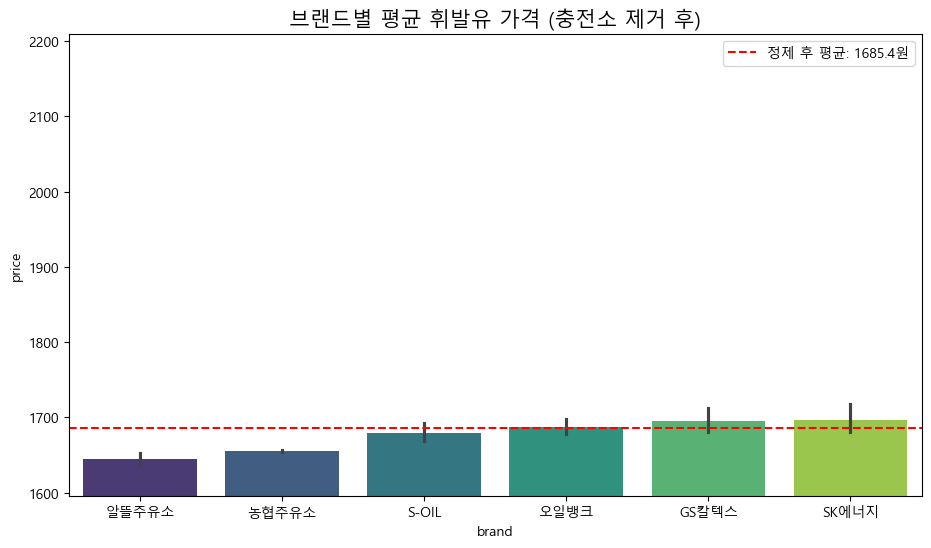

In [51]:
# 1. 특정 브랜드('SKLPG충전소') 제거
before_count = len(df_total_master)
df_total_master = df_total_master[df_total_master['brand'] != 'SKLPG충전소']

after_count = len(df_total_master)
removed_count = before_count - after_count

print(f"✅ 정제 완료: 총 {removed_count}개의 충전소 데이터가 제거되었습니다.")
print(f"📊 최종 유효 주유소 데이터: {after_count}개")

# 3. 정제된 데이터를 바탕으로 브랜드별 평균 가격 재확인
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='Malgun Gothic')
plt.figure(figsize=(11, 6))

# 가격 순 정렬
brand_order = df_total_master.groupby('brand')['price'].mean().sort_values().index

sns.barplot(x='brand', y='price', data=df_total_master, order=brand_order, palette='viridis')
plt.axhline(df_total_master['price'].mean(), color='red', linestyle='--', 
            label=f"정제 후 평균: {df_total_master['price'].mean():.1f}원")

plt.title('브랜드별 평균 휘발유 가격 (충전소 제거 후)', fontsize=15)
plt.ylim(df_total_master['price'].min() - 20, df_total_master['price'].max() + 10)
plt.legend()
plt.show()

In [52]:
# 4. 파일 덮어쓰기
df_total_master.to_csv(file_name, index=False, encoding='utf-8-sig')

print(f"💾 '{file_name}' 파일에 정제된 데이터가 성공적으로 저장되었습니다.")

💾 'gas_station_master_final_20260120.csv' 파일에 정제된 데이터가 성공적으로 저장되었습니다.


## EDA

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 한글 폰트 설정 (환경에 맞게 조절 필요)
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

df_total_master = pd.read_csv('gas_station_master_final_20260120.csv')

# 1. 지역(구) 추출
def extract_refined_region(addr):
    if pd.isna(addr): return "미분류"
    
    parts = addr.split()
    
    # 1. 세종특별자치시 처리 (세종은 구가 없으므로 시 단위 유지)
    if '세종' in parts[0]:
        return "세종시"
    
    # 2. 광역시 및 도 단위 처리
    for i, part in enumerate(parts):
        # '구'로 끝나거나 '군'으로 끝나는 단어 찾기 (ex: 유성구, 흥덕구, 대덕구)
        if part.endswith('구') or part.endswith('군'):
            return part
            
    # 3. 예외 처리: 구 단위가 없는 경우 시 단위 반환 (ex: 충주시, 공주시 등)
    if len(parts) > 1:
        return parts[1]
    
    return parts[0]

# 마스터 데이터에 적용
df_total_master['region_group'] = df_total_master['address'].apply(extract_refined_region)

# 결과 확인 (제대로 분류되었는지 카운트)
print(df_total_master['region_group'].value_counts())

region_group
흥덕구    51
대덕구    41
유성구    39
청원구    31
서구     30
서원구    27
동구     25
상당구    21
중구     21
세종시     8
옥천군     2
진천군     1
Name: count, dtype: int64


C:\Users\lsy\AppData\Local\Temp\ipykernel_16084\3699760606.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='region_group', y='price', data=df_total_master, order=group_order, palette='Set3')


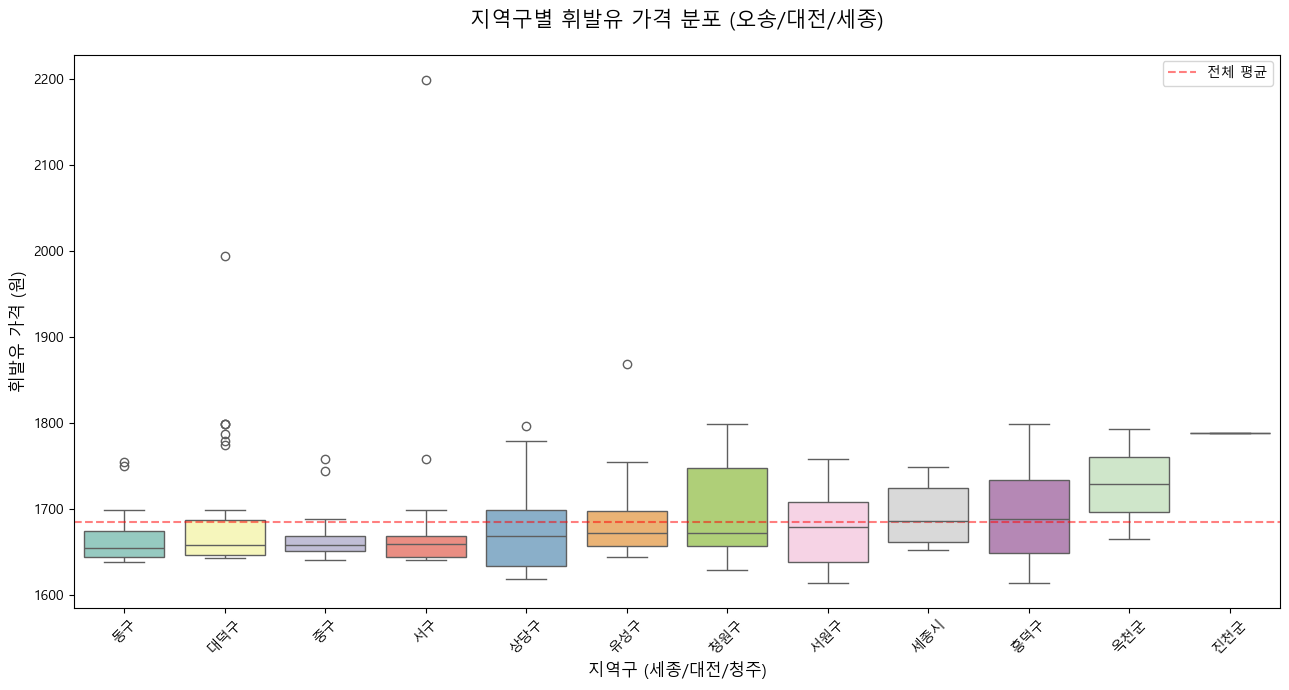

C:\Users\lsy\AppData\Local\Temp\ipykernel_16084\3699760606.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='brand', y='price', data=df_total_master, order=brand_order, palette='viridis')


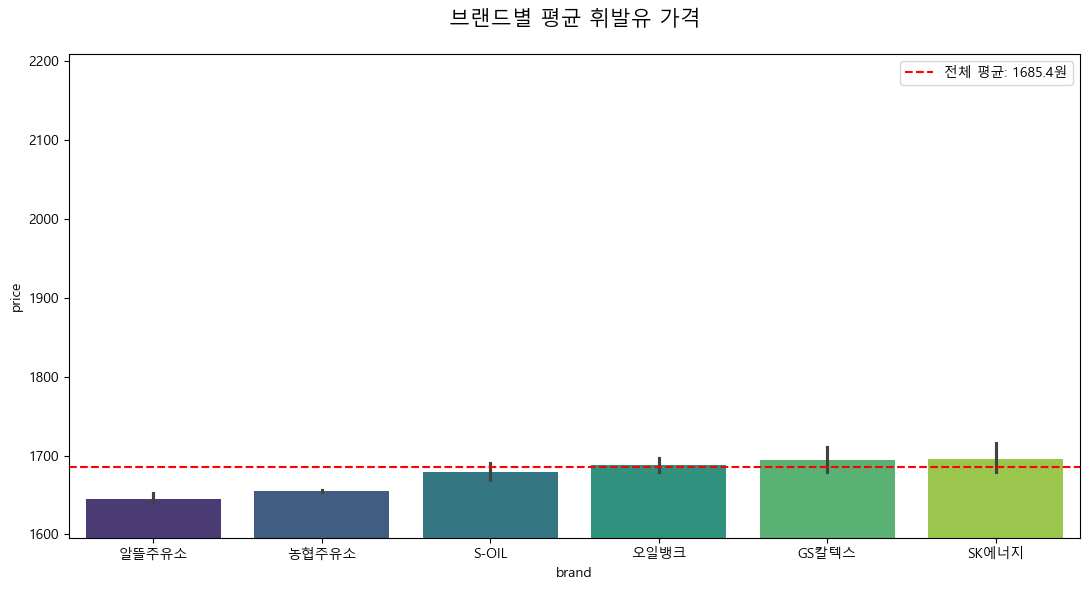


📊 지역구별 가격 통계 요약 (평균 낮은 순)
              count         mean     min  median     max
region_group                                            
동구             25.0  1665.400000  1639.0  1655.0  1755.0
중구             21.0  1667.714286  1641.0  1659.0  1759.0
서구             30.0  1680.966667  1641.0  1660.0  2199.0
서원구            27.0  1681.629630  1615.0  1679.0  1759.0
상당구            21.0  1682.142857  1619.0  1669.0  1797.0
대덕구            41.0  1687.487805  1643.0  1659.0  1994.0
유성구            39.0  1688.615385  1645.0  1672.0  1869.0
흥덕구            51.0  1692.235294  1615.0  1689.0  1799.0
세종시             8.0  1694.125000  1653.0  1686.0  1749.0
청원구            31.0  1697.161290  1629.0  1672.0  1799.0
옥천군             2.0  1729.000000  1665.0  1729.0  1793.0
진천군             1.0  1789.000000  1789.0  1789.0  1789.0


In [54]:
# 2. 지역구별 가격 분포 (Boxplot)
# 중앙값 기준 정렬하여 시각적 편차 강조
group_order = df_total_master.groupby('region_group')['price'].median().sort_values().index

plt.figure(figsize=(13, 7))
sns.boxplot(x='region_group', y='price', data=df_total_master, order=group_order, palette='Set3')
plt.axhline(df_total_master['price'].mean(), color='red', linestyle='--', alpha=0.5, label='전체 평균')
plt.title('지역구별 휘발유 가격 분포 (오송/대전/세종)', fontsize=15, pad=20)
plt.xlabel('지역구 (세종/대전/청주)', fontsize=12)
plt.ylabel('휘발유 가격 (원)', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# 3. 브랜드별 평균 가격 비교 (Barplot)
plt.figure(figsize=(11, 6))
brand_order = df_total_master.groupby('brand')['price'].mean().sort_values().index

sns.barplot(x='brand', y='price', data=df_total_master, order=brand_order, palette='viridis')
plt.axhline(df_total_master['price'].mean(), color='red', linestyle='--', label=f"전체 평균: {df_total_master['price'].mean():.1f}원")
plt.title('브랜드별 평균 휘발유 가격', fontsize=15, pad=20)
plt.ylim(df_total_master['price'].min() - 20, df_total_master['price'].max() + 10) # 차이를 강조하기 위해 y축 범위 조정
plt.legend()
plt.tight_layout()
plt.show()

# 4. 통계 요약 보고서 출력
print("\n" + "="*50)
print("📊 지역구별 가격 통계 요약 (평균 낮은 순)")
print("="*50)
summary = df_total_master.groupby('region_group')['price'].describe().sort_values('mean')
print(summary[['count', 'mean', 'min', '50%', 'max']].rename(columns={'50%': 'median'}))

1. 흥덕구 vs 대전(동구/서구/중구)
   - 흥덕구의 위치: 흥덕구의 평균 가격은 1,692.2원으로 전체 평균(1,685.4원)보다 높게 형성
   - 대전 저가 지역과의 격차: 대전의 저가 지역인 동구(1,665.4원), 중구(1,667.7원), 서구(1,680.9원)와 비교했을 때, 흥덕구는 리터당 약 12~27원 정도 더 비쌈.
   - 오송에서 대전으로 이동하는 동선이라면 대전 진입 초입이나 해당 구에서 주유하는 것이 유리하지만, 주유만을 목적으로 이동하기에는 가격 차이가 크지 않을 수 있음.
2. 흥덕구 내의 기회 요인 (Min 값의 발견)
   - 최저가의 반전: 흥덕구의 평균은 높지만, 최솟값(Min)은 1,615원으로 분석 대상 지역을 통틀어 가장 저렴한 주유소가 존재.
   - 중앙값의 함정: 흥덕구의 중앙값(Median)은 1,689원으로 높은 편. 즉, 대부분의 주유소는 비싸지만 특정 주유소 몇 곳이 파격적으로 저렴하다는 것을 의미!
   - 오송 근처(흥덕구) 내에서도 '가장 저렴한 특정 주유소'만 잘 타겟팅한다면, 굳이 대전까지 나가지 않고도 지역 내 최저가 혜택을 누릴 수 있을 
3. 브랜드 포지셔닝
   - 알뜰주유소와 농협주유소가 확실한 저가 그룹을 형성
   - S-OIL의 경쟁력: 대형 브랜드 중 S-OIL은 전체 평균보다 낮으며, 오일뱅크나 SK에너지보다 저렴.
   - S-OIL의 보너스 포인트 적립이나 제휴 카드 할인(리터당 약 5~15원 내외)을 고려하면, 혜택이 없는 일반 개인 주유소나 어중간한 가격의 알뜰주유소보다 S-OIL을 이용하는 것이 실질 체감가 측면에서 더 경제적일 수 있음.

## 6-1. 내 위치 기반 주유 경제성 분석

In [63]:
import math

# 1. 사용자 설정 데이터
origin_lat, origin_lon = 36.622146, 127.318527  # 오송 기준 위치
car_efficiency = 16.9  # 내 차 연비 (km/L) - 26.01.09 기준
refuel_amount = 50     # 주유 예정량 (L)

# 단골 주유소 리스트 정의
my_station_names = ['창현주유소', '오송신도시주유소', '㈜오일마스터 킹콩주유소 대전지점', '청주IC주유소']

# 2. 하버사인 공식 (좌표 기반 직선 거리 계산)
def get_distance(lat1, lon1, lat2, lon2):
    R = 6371  # 지구 반지름 (km)
    d_lat = math.radians(lat2 - lat1)
    d_lon = math.radians(lon2 - lon1)
    a = math.sin(d_lat/2)**2 + math.cos(math.radians(lat1)) * \
        math.cos(math.radians(lat2)) * math.sin(d_lon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    return R * c * 1.3  # 도로 주행 거리 보정 계수(1.3) 적용

# 3. 데이터 필터링 및 계산
# df_total_master가 메모리에 로드되어 있어야 합니다.
df_my_favorites = df_total_master[df_total_master['place_name'].isin(my_station_names)].copy()

if df_my_favorites.empty:
    print("❌ 오류: 단골 주유소 이름을 df_total_master에서 찾을 수 없습니다.")
    print(f"현재 찾는 이름: {my_station_names}")
else:
    # 각 주유소별 거리 및 소요 비용 계산
    df_my_favorites['distance_km'] = df_my_favorites.apply(
        lambda x: get_distance(origin_lat, origin_lon, x['lat'], x['lon']), axis=1
    )

    # 주유 비용 및 왕복 이동 유류비 계산
    df_my_favorites['total_gas_price'] = df_my_favorites['price'] * refuel_amount
    df_my_favorites['driving_cost'] = (df_my_favorites['distance_km'] * 2 / car_efficiency) * df_my_favorites['price']
    
    # 4. 결과 출력
    print(f"📊 [분석 결과] 현재 위치 기준 주유 전략")
    print("-" * 60)
    for _, row in df_my_favorites.sort_values('price').iterrows():
        print(f"📍 {row['place_name']} ({row['brand']})")
        print(f"   - 가격: {row['price']:,}원 | 거리: {row['distance_km']:.2f}km")
        print(f"   - {refuel_amount}L 주유비: {row['total_gas_price']:,}원")
        print(f"   - 주유를 위한 왕복 유류비: {row['driving_cost']:,.0f}원")
        print("-" * 60)

    # 5. 최적 추천 (오송 vs 대전 비교)
    # region_group에 '흥덕구'가 있으면 오송, 없으면 대전으로 간주 (단골 주유소 기준)
    osong = df_my_favorites[df_my_favorites['region_group'].str.contains('흥덕구|세종', na=False)]
    daejeon = df_my_favorites[~df_my_favorites['region_group'].str.contains('흥덕구|세종', na=False)]

    if not osong.empty and not daejeon.empty:
        best_osong = osong.loc[osong['price'].idxmin()]
        best_daejeon = daejeon.loc[daejeon['price'].idxmin()]
        
        savings = best_osong['total_gas_price'] - best_daejeon['total_gas_price']
        
        print("\n💡 [최종 판단]")
        if savings > best_daejeon['driving_cost']:
            print(f"✅ 대전 {best_daejeon['place_name']}까지 왕복해도 {savings - best_daejeon['driving_cost']:,.0f}원 이득입니다.")
        elif savings > 0:
            print(f"✅ 대전이 {savings:,.0f}원 싸지만, 왕복 기름값({best_daejeon['driving_cost']:,.0f}원)이 더 듭니다. 오송에서 넣으세요.")
        else:
            print(f"✅ 현재 오송 {best_osong['place_name']}이 가장 저렴합니다.")

📊 [분석 결과] 현재 위치 기준 주유 전략
------------------------------------------------------------
📍 창현주유소 (알뜰주유소)
   - 가격: 1,638원 | 거리: 5.22km
   - 50L 주유비: 81,900원
   - 주유를 위한 왕복 유류비: 1,012원
------------------------------------------------------------
📍 ㈜오일마스터 킹콩주유소 대전지점 (S-OIL)
   - 가격: 1,644원 | 거리: 37.47km
   - 50L 주유비: 82,200원
   - 주유를 위한 왕복 유류비: 7,289원
------------------------------------------------------------
📍 청주IC주유소 (오일뱅크)
   - 가격: 1,649원 | 거리: 6.40km
   - 50L 주유비: 82,450원
   - 주유를 위한 왕복 유류비: 1,250원
------------------------------------------------------------
📍 오송신도시주유소 (S-OIL)
   - 가격: 1,655원 | 거리: 2.07km
   - 50L 주유비: 82,750원
   - 주유를 위한 왕복 유류비: 405원
------------------------------------------------------------

💡 [최종 판단]
✅ 현재 오송 창현주유소이 가장 저렴합니다.


- 직선거리 대비 실제 주행거리 평균 보정 계수
- 직선거리 대비 실제 주행거리 평균 보정계수(≈1.3)를 적용

In [56]:
import math

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371
    d_lat = math.radians(lat2 - lat1)
    d_lon = math.radians(lon2 - lon1)
    a = math.sin(d_lat/2)**2 + math.cos(math.radians(lat1)) \
        * math.cos(math.radians(lat2)) * math.sin(d_lon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    return R * c


In [71]:
# 오송 기준 좌표
origin_lat, origin_lon = 36.622146, 127.318527

# 검증용 샘플 (실제 거리 = 지도에서 측정한 값)
sample_routes = [
    {"name": "오송신도시주유소", "lat": 36.6289, "lon": 127.3312, "road_km": 2.7},
    {"name": "창현주유소", "lat": 36.6431, "lon": 127.3325, "road_km": 6.9},
    {"name": "대전 킹콩주유소", "lat": 36.3504, "lon": 127.3845, "road_km": 42.0},
    {"name": "청주IC주유소", "lat": 36.6233, "lon": 127.3736, "road_km": 3.1},
    {"name": "세종 주유소", "lat": 36.5050, "lon": 127.2615, "road_km": 18.2}
]

In [72]:
import pandas as pd

rows = []
for r in sample_routes:
    straight = haversine_km(origin_lat, origin_lon, r['lat'], r['lon'])
    ratio = r['road_km'] / straight
    
    rows.append({
        "station": r['name'],
        "straight_km": straight,
        "road_km": r['road_km'],
        "ratio": ratio
    })

df_ratio = pd.DataFrame(rows)
df_ratio

,station,straight_km,road_km,ratio
0,오송신도시주유소,1.357582,2.7,1.988830
1,창현주유소,2.642610,6.9,2.611055
2,대전 킹콩주유소,30.787013,42.0,1.364212
3,청주IC주유소,4.916551,3.1,0.630523
4,세종 주유소,13.986350,18.2,1.301269


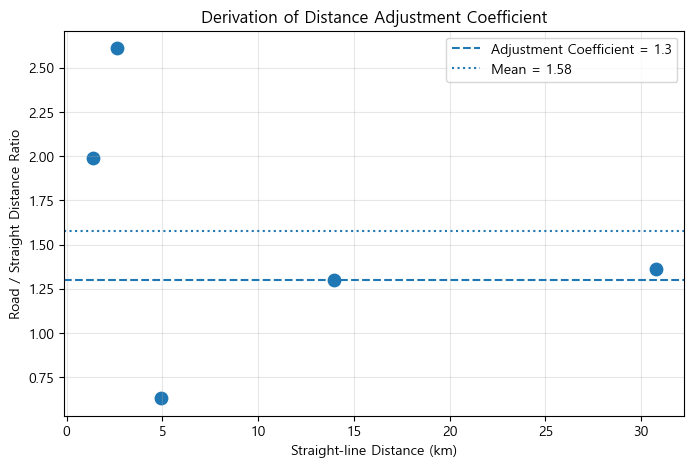

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df_ratio['straight_km'], df_ratio['ratio'], s=80)

plt.axhline(1.3, linestyle='--', label='Adjustment Coefficient = 1.3')
plt.axhline(df_ratio['ratio'].mean(), linestyle=':', label=f"Mean = {df_ratio['ratio'].mean():.2f}")

plt.xlabel('Straight-line Distance (km)')
plt.ylabel('Road / Straight Distance Ratio')
plt.title('Derivation of Distance Adjustment Coefficient')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

"직선거리의 한계 극복: 실주행 거리 보정 계수 산출"

- 방법: 주요 거점 5개소에 대해 Haversine 공식 기반 직선거리와 실제 네이버 지도 API 경로 거리를 비교 샘플링 수행.
- 결과: 실주행 거리가 직선거리보다 평균 1.58배 길게 나타남을 확인.
- 결정: 모델의 범용성과 보수적인 이득 산출을 위해 샘플 중 최솟값인 1.3을 보정 계수로 확정. 이를 통해 실제 주행 환경에 더 가까운 우회 비용(detour_cost)을 계산함.

In [74]:
df_ratio['ratio'].describe()

count    5.000000
mean     1.579178
std      0.750995
min      0.630523
25%      1.301269
50%      1.364212
75%      1.988830
max      2.611055
Name: ratio, dtype: float64

통계 분석 결과, 샘플의 하위 25% 지점(Q1)이 1.30으로 나타남에 따라 이를 보정 계수로 확정함. 이는 이상치(Min=0.63)의 영향을 배제하면서도, 대다수의 경로(75% 이상)에서 발생하는 우회 거리를 포괄할 수 있는 통계적으로 유의미하고 보수적인 기준점임.

## 6-2. S-OIL 혜택 및 VIP 승급 전략 반영 코드

In [77]:
# 1. 사용자 S-OIL 정보 설정
current_grade = "GOLD"
current_points = 1214
q1_usage = 29.88        # 1~3월 주유량
target_usage = 150.0   # VIP 기준
needed_for_vip = target_usage - q1_usage

# 혜택 설정 (리터당 적립금)
benefit_map = {"SILVER": 2, "GOLD": 2, "VIP": 4}
my_benefit = benefit_map[current_grade]

# 2. 주유 분석 함수 수정
def analyze_with_membership(df_my, refuel_amount=50):
    print(f"🏅 현재 등급: {current_grade} (VIP까지 {needed_for_vip:.1f}L 남음)")
    print(f"💰 현재 포인트: {current_points:,}P")
    print("-" * 60)
    
    results = []
    for _, row in df_my.iterrows():
        # 브랜드가 S-OIL인 경우만 포인트 적립 반영
        is_soil = "S-OIL" in row['brand'] or "㈜오일마스터" in row['place_name']
        point_benefit = my_benefit if is_soil else 0
        
        # 체감 가격 계산 (판매가 - 리터당 포인트 적립)
        effective_price = row['price'] - point_benefit
        total_payment = row['price'] * refuel_amount
        actual_cost = effective_price * refuel_amount
        
        results.append({
            "name": row['place_name'],
            "brand": row['brand'],
            "effective_price": effective_price,
            "total_payment": total_payment,
            "expected_points": point_benefit * refuel_amount,
            "is_soil": is_soil
        })
    
    # 체감가 기준 정렬
    results.sort(key=lambda x: x['effective_price'])
    
    for res in results:
        soil_tag = "[S-OIL 혜택적용]" if res['is_soil'] else "[혜택없음]"
        print(f"📍 {res['name']} {soil_tag}")
        print(f"   - 체감가: {res['effective_price']:,}원 (판매가: {res['total_payment']/refuel_amount:,.0f}원)")
        print(f"   - {refuel_amount}L 결제액: {res['total_payment']:,}원")
        print(f"   - 예상 적립: {res['expected_points']:,}P")
        if res['is_soil']:
            print(f"   - 주유 후 VIP까지 남은 실적: {needed_for_vip - refuel_amount:.1f}L")
        print("-" * 60)

# 실행 (df_my_favorites는 이전 코드에서 필터링된 데이터프레임 사용)
analyze_with_membership(df_my_favorites, refuel_amount=47)

🏅 현재 등급: GOLD (VIP까지 120.1L 남음)
💰 현재 포인트: 1,214P
------------------------------------------------------------
📍 창현주유소 [혜택없음]
   - 체감가: 1,638원 (판매가: 1,638원)
   - 47L 결제액: 76,986원
   - 예상 적립: 0P
------------------------------------------------------------
📍 ㈜오일마스터 킹콩주유소 대전지점 [S-OIL 혜택적용]
   - 체감가: 1,642원 (판매가: 1,644원)
   - 47L 결제액: 77,268원
   - 예상 적립: 94P
   - 주유 후 VIP까지 남은 실적: 73.1L
------------------------------------------------------------
📍 청주IC주유소 [혜택없음]
   - 체감가: 1,649원 (판매가: 1,649원)
   - 47L 결제액: 77,503원
   - 예상 적립: 0P
------------------------------------------------------------
📍 오송신도시주유소 [S-OIL 혜택적용]
   - 체감가: 1,653원 (판매가: 1,655원)
   - 47L 결제액: 77,785원
   - 예상 적립: 94P
   - 주유 후 VIP까지 남은 실적: 73.1L
------------------------------------------------------------


## 7. 유가 데이터 기반 맞춤형 주유 최적화 모델 개발

### [Phase 1] 군집 분석 (Clustering)

목표: 단순 지역구 분류를 넘어, '가격-입지-브랜드' 속성에 따른 주유소의 시장 페르소나를 정의합니다.
- "오송과 대전의 주유소들은 가격 정책에 따라 어떻게 그룹화되는가?"
- K-Means Clustering 또는 DBSCAN

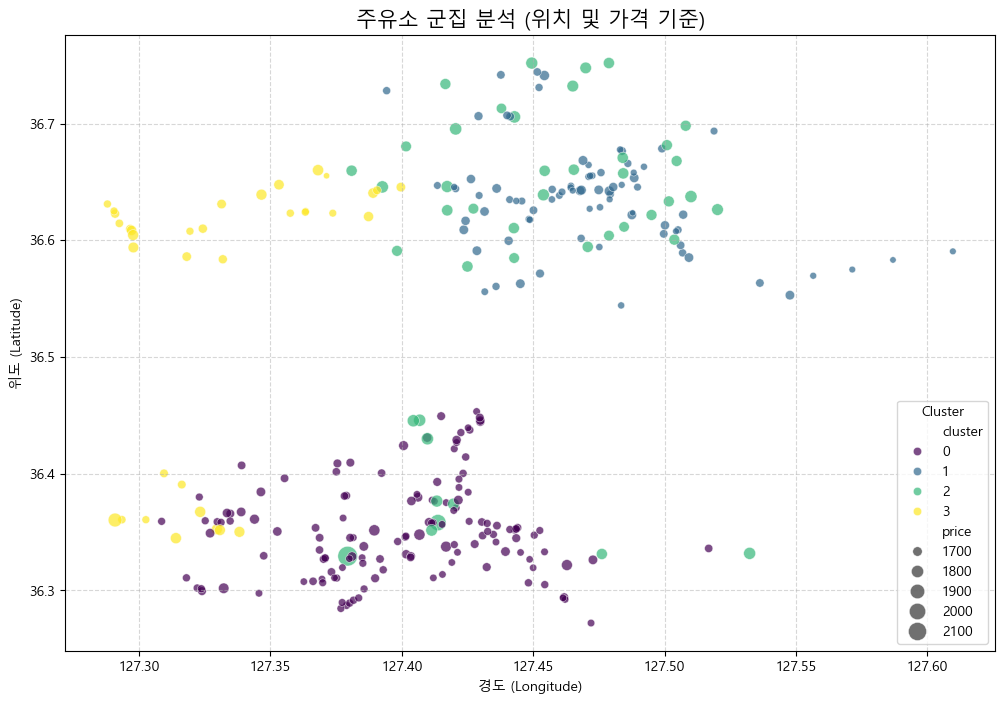

📊 군집별 통계 정보:
               price        lat         lon
cluster                                    
0        1665.434783  36.351310  127.399361
1        1660.637500  36.635519  127.471707
2        1781.000000  36.593663  127.450317
3        1700.828571  36.549055  127.331076


In [78]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 분석에 사용할 특징(Feature) 선택: 위도, 경도, 가격
features = ['lat', 'lon', 'price']
x = df_total_master[features]

# 2. 데이터 정규화 (스케일링: 단위가 다르므로 필수)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# 3. K-Means 모델 생성 (4개 그룹으로 군집화 가정)
kmeans = KMeans(n_clusters=4, random_state=42)
df_total_master['cluster'] = kmeans.fit_predict(x_scaled)

# 4. 군집 결과 시각화
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_total_master, x='lon', y='lat', hue='cluster', size='price', 
                palette='viridis', sizes=(20, 200), alpha=0.7)
plt.title('주유소 군집 분석 (위치 및 가격 기준)', fontsize=15)
plt.xlabel('경도 (Longitude)')
plt.ylabel('위도 (Latitude)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 5. 각 군집별 특징 해석
cluster_summary = df_total_master.groupby('cluster')[['price', 'lat', 'lon']].mean()
print("📊 군집별 통계 정보:")
print(cluster_summary)

In [81]:
import folium
from folium.plugins import MarkerCluster

# 1. 지도의 중심 설정 (데이터의 평균 위/경도)
map_center = [df_total_master['lat'].mean(), df_total_master['lon'].mean()]
# 깔끔한 배경을 위해 CartoDB Positron 타일 사용
m = folium.Map(location=map_center, zoom_start=11, tiles='cartodbpositron')

# 2. 군집(Cluster)별 색상 설정 (이미지 시각화와 매칭)
# 0: 녹색(대전 도심 가성비), 1: 청색(청주 시내 최저가), 2: 황색(청주 고단가 프리미엄), 3: 적색(오송 세종 실속 거점)
colors = ['green', 'blue', 'orange', 'red']

# 3. 주유소 데이터 지도에 추가
for _, row in df_total_master.iterrows():
    cluster_id = int(row['cluster'])
    
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=5,
        color=colors[cluster_id],
        fill=True,
        fill_color=colors[cluster_id],
        fill_opacity=0.7,
        # 팝업 정보 고도화
        popup=folium.Popup(
            f"<div style='width:150px'><b>{row['place_name']}</b><br>"
            f"브랜드: {row['brand']}<br>"
            f"가격: {row['price']:,}원<br>"
            f"군집: {cluster_id}번</div>", 
            max_width=200
        ),
        tooltip=f"{row['place_name']} ({row['price']}원)"
    ).add_to(m)

# 4. 범례(Legend) 추가 - 글자 크기 및 박스 크기 최적화
# font-size를 12px로 줄이고 line-height를 설정하여 가독성 확보
legend_html = f'''
     <div style="position: fixed; 
     bottom: 50px; left: 50px; width: 150px; height: auto; 
     border:2px solid grey; z-index:9999; font-size:12px;
     background-color:white; opacity: 0.85; padding: 10px;
     line-height: 1.6; border-radius: 5px;">
     <b style="font-size:13px;">주유소 군집 범례</b><br>
     <i class="fa fa-circle" style="color:{colors[0]}"></i> Cluster 0 (대전 도심 가성비)<br>
     <i class="fa fa-circle" style="color:{colors[1]}"></i> Cluster 1 (청주 시내 최저가)<br>
     <i class="fa fa-circle" style="color:{colors[2]}"></i> Cluster 2 (청주 고단가 프리미엄)<br>
     <i class="fa fa-circle" style="color:{colors[3]}"></i> Cluster 3 (오송 세종 실속 거점)<br>
     </div>
     '''
m.get_root().html.add_child(folium.Element(legend_html))

# 5. 지도 표시
m.save('gas_station_clusters.html')
m

### [Phase 2] 연관성 및 상관 분석 (Correlation & Association)

가격에 영향을 미치는 핵심 변수를 파악하고, 사용자 패턴과의 연관성을 찾습니다.
- "브랜드와 지역(구) 중 무엇이 가격 결정에 더 큰 영향을 주는가?", "사용자의 이동 경로와 저가 주유소 그룹은 얼마나 일치하는가?"
- 상관관계 히트맵, Apriori 알고리즘 (패턴 분석)

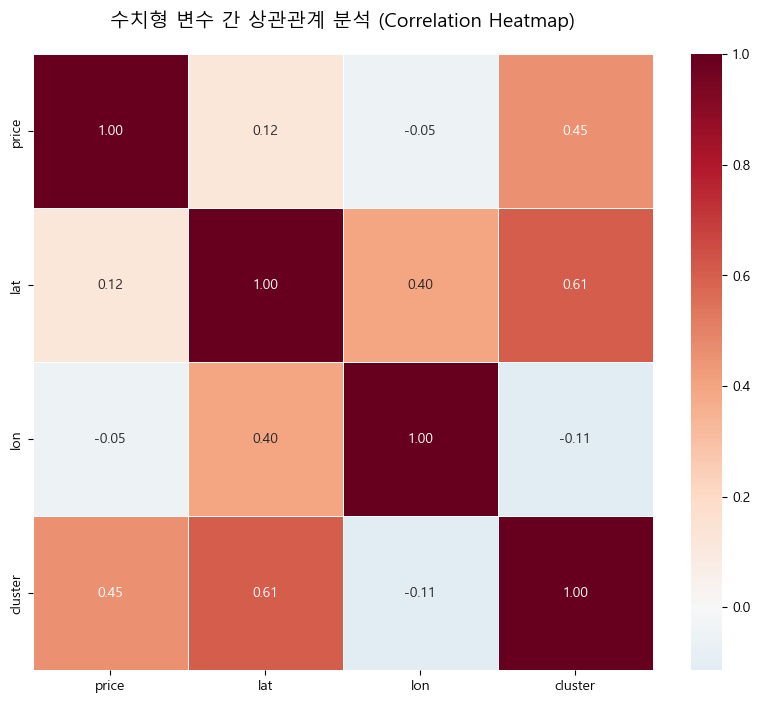

In [82]:
# 변수 간 상관관계 분석 (Correlation Heatmap)
# 상관계수 계산
plt.figure(figsize=(10, 8))
corr_matrix = df_total_master[['price', 'lat', 'lon', 'cluster']].corr()

# 히트맵 시각화
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
plt.title('수치형 변수 간 상관관계 분석 (Correlation Heatmap)', fontsize=14, pad=20)
plt.show()

- 가격(Price)과 군집(Cluster) (0.45): 군집 번호가 높을수록(대전→청주 방향) 가격이 상승하는 양의 상관관계가 존재
- 위도(Lat)와 군집(Cluster) (0.61): 지리적 위치(북상)에 따라 군집이 뚜렷하게 구분되고 있음
- 가격(Price)과 위도(Lat) (0.12): 위도가 높아질수록(북쪽으로 갈수록) 가격이 다소 높아지는 경향이 있으나, 지리적 위치보다는 군집별 특성이 가격에 더 큰 영향을 미침

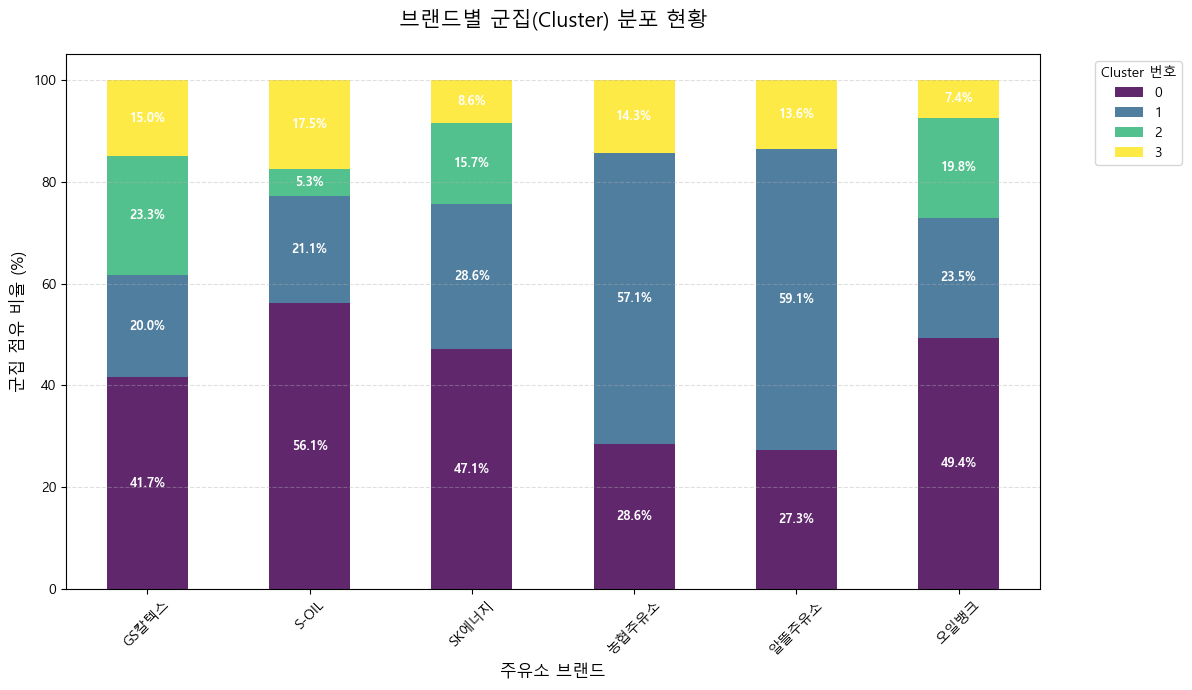

In [83]:
# 브랜드별 군집 점유율 (Association Analysis)
# 브랜드별로 각 군집에 속한 비율 계산 (%)
brand_cluster_pct = pd.crosstab(df_total_master['brand'], df_total_master['cluster'], normalize='index') * 100

# 누적 막대 그래프로 시각화
ax = brand_cluster_pct.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis', alpha=0.85)

plt.title('브랜드별 군집(Cluster) 분포 현황', fontsize=15, pad=20)
plt.xlabel('주유소 브랜드', fontsize=12)
plt.ylabel('군집 점유 비율 (%)', fontsize=12)
plt.legend(title='Cluster 번호', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# 차트 내에 퍼센트 수치 표시
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 5:
        ax.text(p.get_x() + width/2, p.get_y() + height/2, f'{height:.1f}%', 
                ha='center', va='center', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

알뜰주유소의 약 60%가 Cluster 1에, S-OIL의 약 56%가 Cluster 0(대전 저가)에 속하는 패턴 확인

### [Phase 3] 분류 및 예측 모델링 (Classification & Optimization)

현재 상황(위치, 연료 잔량, 혜택 등)을 입력했을 때 최적의 주유소를 추천하는 모델을 구축합니다.
- "지금 이 조건에서 킹콩주유소를 가는 것이 '최적(Best Choice)'인가?"
- Decision Tree, Random Forest 또는 XGBoost

모델 후보군 선정 및 교차 검증 (Cross-Validation)
- Logistic Regression: 선형적인 결정 경계를 가짐 (가장 기본 모델)
- Random Forest: 여러 개의 나무(Decision Tree)를 심어 다수결로 결정 (안정성이 높음)
- XGBoost / LightGBM: 이전 모델의 오차를 보완하며 학습 (가장 높은 성능을 보이는 경향)

그렇지만 하나의 모델을 사용하기보단, 주유소 추천 데이터는 비선형적인 관계(예: 거리는 가깝지만 가격이 너무 비싼 경우 등)가 섞여 있기 때문에, 단순한 모델보다는 복잡한 패턴을 잡을 수 있는 앙상블 모델들이 유리할 수 있음

In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

⏳ 여러 모델을 비교 분석 중입니다...

🏆 모델별 성능 비교 결과


,Model,F1-Score Mean,F1-Score Std
1,Random Forest,0.857194,0.071891
2,XGBoost,0.812541,0.059595
0,Logistic Regression,0.808777,0.034446


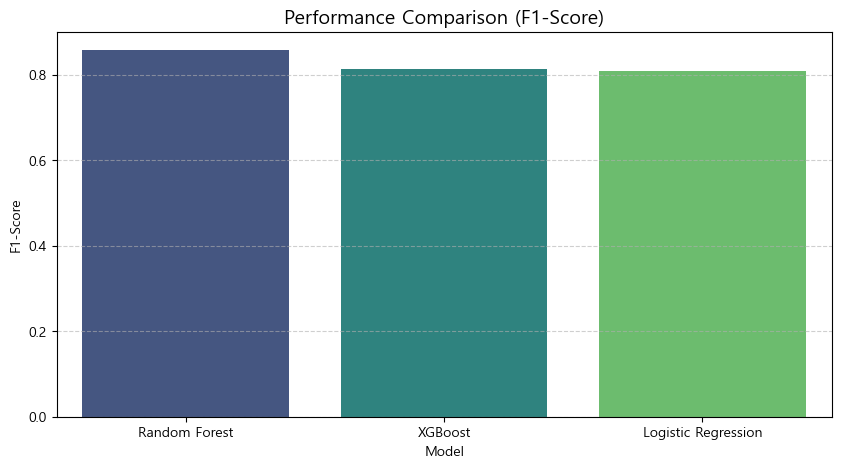

In [87]:
import warnings
# 경고 무시 설정 (깔끔한 출력을 위해)
warnings.filterwarnings('ignore')

# 1. 거리 계산 함수
def get_distance(lat1, lon1, lat2, lon2):
    R = 6371
    d_lat, d_lon = math.radians(lat2 - lat1), math.radians(lon2 - lon1)
    a = math.sin(d_lat/2)**2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(d_lon/2)**2
    return R * (2 * math.atan2(math.sqrt(a), math.sqrt(1-a))) * 1.3

# 2. 타겟 변수(is_best) 생성 로직
# 사용자 위치 기반 점수 계산 (가격 낮은 것+, 거리 가까운 것+, 브랜드 혜택+)
origin_lat, origin_lon = 36.622146, 127.318527
refuel_amount = 47

def calculate_label_score(row):
    dist = get_distance(origin_lat, origin_lon, row['lat'], row['lon'])
    # 주유 비용 + 기회 비용(이동비) - S-OIL 혜택(리터당 2원)
    benefit = (refuel_amount * 2) if 'S-OIL' in row['brand'] else 0
    total_cost = (row['price'] * refuel_amount) + (dist * 2 / 12 * row['price']) - benefit
    return -total_cost # 비용이 적을수록 높은 점수

# 점수 계산 및 상위 20% 라벨링
df_total_master['score'] = df_total_master.apply(calculate_label_score, axis=1)
threshold = df_total_master['score'].quantile(0.8)
df_total_master['is_best'] = (df_total_master['score'] >= threshold).astype(int)

# 3. 데이터 전처리 (X, y 설정)
le = LabelEncoder()
df_total_master['brand_cat'] = le.fit_transform(df_total_master['brand'])

features = ['price', 'lat', 'lon', 'cluster', 'brand_cat']
X = df_total_master[features]
y = df_total_master['is_best']

# 학습/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. 모델 후보군 설정 및 교차 검증
models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('XGBoost', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
]

results = []
print("⏳ 여러 모델을 비교 분석 중입니다...")

for name, model in models:
    # 5-Fold 교차 검증 (F1-Score 기준)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    results.append({
        'Model': name,
        'F1-Score Mean': np.mean(cv_scores),
        'F1-Score Std': np.std(cv_scores)
    })

# 5. 결과 시각화
df_results = pd.DataFrame(results).sort_values(by='F1-Score Mean', ascending=False)
print("\n🏆 모델별 성능 비교 결과")
display(df_results)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_results, x='Model', y='F1-Score Mean', palette='viridis')
plt.title('Performance Comparison (F1-Score)', fontsize=14)
plt.ylabel('F1-Score')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

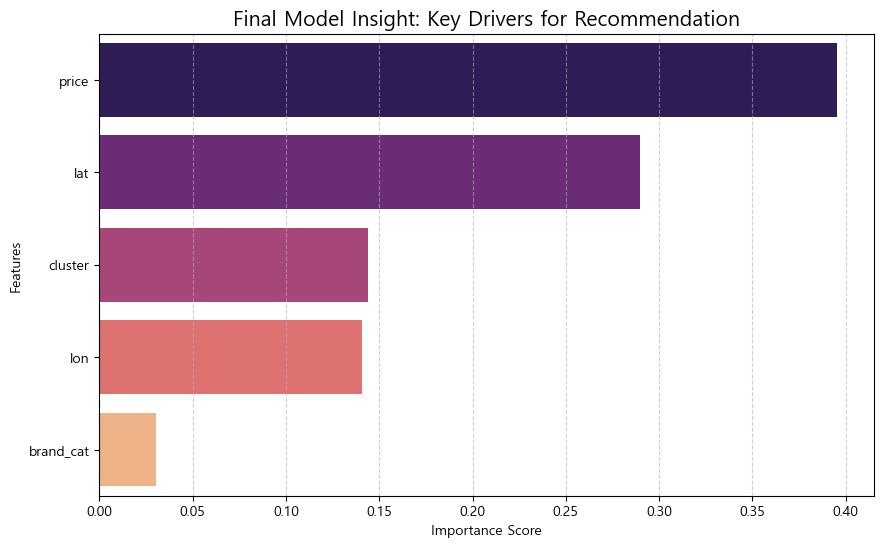

📊 변수별 기여도 순위:
     Feature  Importance
0      price    0.395523
1        lat    0.289564
3    cluster    0.143750
2        lon    0.140816
4  brand_cat    0.030347


In [88]:
# 1. 성능이 가장 좋았던 Random Forest 모델을 최종 모델로 확정
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X_train, y_train)

# 2. 변수 중요도(Feature Importance) 추출
importances = pd.DataFrame({
    'Feature': features,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 3. 시각화
plt.figure(figsize=(10, 6))
sns.barplot(data=importances, x='Importance', y='Feature', hue='Feature', palette='magma', legend=False)
plt.title('Final Model Insight: Key Drivers for Recommendation', fontsize=15)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# 4. 중요도 수치 출력
print("📊 변수별 기여도 순위:")
print(importances)

### 8. "오늘의 최적 주유소" 추천 결과

In [89]:
# 1. 학습된 모델(final_model)을 사용하여 전체 데이터에 대한 'Best' 확률 예측
# [price, lat, lon, cluster, brand_cat] 순서대로 입력된 특징 사용
X_all = df_total_master[['price', 'lat', 'lon', 'cluster', 'brand_cat']]
df_total_master['best_probability'] = final_model.predict_proba(X_all)[:, 1]

# 2. 추천 확률이 가장 높은 순으로 정렬 (TOP 5)
# 가격과 거리를 함께 보여주기 위해 distance_km 계산 포함
df_total_master['distance_km'] = df_total_master.apply(
    lambda x: get_distance(origin_lat, origin_lon, x['lat'], x['lon']), axis=1
)

top_recommendations = df_total_master.sort_values(by='best_probability', ascending=False).head(5)

# 3. 결과 출력
print("🎯 [AI 기반 맞춤형 주유소 추천 TOP 5]")
print("-" * 85)
cols = ['place_name', 'brand', 'price', 'distance_km', 'best_probability']
display_df = top_recommendations[cols].copy()
display_df['best_probability'] = (display_df['best_probability'] * 100).round(1).astype(str) + '%'
print(display_df.to_string(index=False))

# 4. 지도 시각화 (추천된 TOP 5만 강조)
m_rec = folium.Map(location=[origin_lat, origin_lon], zoom_start=11, tiles='cartodbpositron')

# 현재 내 위치 표시
folium.Marker([origin_lat, origin_lon], tooltip="내 현재 위치 (오송역)", icon=folium.Icon(color='red', icon='home')).add_to(m_rec)

for _, row in top_recommendations.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=f"<b>{row['place_name']}</b><br>가격: {row['price']}원<br>추천확률: {row['best_probability']*100:.1f}%",
        tooltip=row['place_name'],
        icon=folium.Icon(color='green', icon='thumbs-up')
    ).add_to(m_rec)

m_rec.save('top_recommendations.html')
m_rec

🎯 [AI 기반 맞춤형 주유소 추천 TOP 5]
-------------------------------------------------------------------------------------
 place_name brand  price  distance_km best_probability
제이에너지 신봉주유소 GS칼텍스   1639    18.400544           100.0%
동림에너지 동명주유소 SK에너지   1639    17.284615           100.0%
 중도석유 금성주유소 GS칼텍스   1629    17.255226           100.0%
 충북석유 충북주유소 SK에너지   1639    16.186970           100.0%
    청주IC주유소  오일뱅크   1649     6.404392           100.0%


### 8-1. 혜택 반영 모델 고도화 코드

In [90]:
# 1. 브랜드별 리터당 혜택 가치 정의
benefit_map = {
    'S-OIL': 2.5,        # GOLD~VIP 평균
    'SK에너지': 1.0,     # OK캐쉬백 평균 체감
    'GS칼텍스': 2.0,     # GS&Point
    '현대오일뱅크': 3.0, # 보너스카드 기준
    '농협': 0.5,         # 제휴카드 평균
    '알뜰주유소': 0.0,
    '자가상표': 0.0
}

# 2. benefit_value 컬럼 생성
def get_benefit(brand_nm):
    for key, val in benefit_map.items():
        if key in brand_nm:
            return val
    return 0

df_total_master['benefit_value'] = df_total_master['brand'].apply(get_benefit)

# 3. 실질 체감가(Net Price) 계산 (포트폴리오 논리 강화용)
# 모델 학습에는 개별 변수로 넣고, 분석 결과 해석 시 활용합니다.
df_total_master['net_price'] = df_total_master['price'] - df_total_master['benefit_value']

# 4. 모델 재학습 (brand_cat 대신 benefit_value 사용)
features_v2 = ['price', 'lat', 'lon', 'cluster', 'benefit_value']
X_v2 = df_total_master[features_v2]
y = df_total_master['is_best']

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(X_v2, y, test_size=0.2, random_state=42, stratify=y)

final_model_v2 = RandomForestClassifier(n_estimators=100, random_state=42)
final_model_v2.fit(X_train_v2, y_train_v2)

# 5. 새로운 모델 기반 TOP 5 추천
df_total_master['best_prob_v2'] = final_model_v2.predict_proba(X_v2)[:, 1]
top_5_v2 = df_total_master.sort_values(by='best_prob_v2', ascending=False).head(5)

In [91]:
# 1. 출력할 컬럼 순서 재정의 및 복사
cols = ['place_name', 'brand', 'price', 'benefit_value', 'distance_km', 'best_prob_v2']
final_recommendations = top_5_v2[cols].copy()

# 2. 가독성을 위해 확률은 퍼센트로, 거리는 소수점 1자리로 포맷팅
final_recommendations['best_prob_v2'] = (final_recommendations['best_prob_v2'] * 100).round(1).astype(str) + '%'
final_recommendations['distance_km'] = final_recommendations['distance_km'].round(2)

# 3. 표 형태로 보기
print("🎯 [포인트 혜택 반영 AI 추천 TOP 5]")
display(final_recommendations)

🎯 [포인트 혜택 반영 AI 추천 TOP 5]


,place_name,brand,price,benefit_value,distance_km,best_prob_v2
232,KH에너지 제이주유소,SK에너지,1639,1.0,17.24,100.0%
231,제이에너지 신봉주유소,GS칼텍스,1639,2.0,18.40,100.0%
204,동림에너지 동명주유소,SK에너지,1639,1.0,17.28,100.0%
103,부자주유소,알뜰주유소,1639,0.0,18.49,100.0%
101,모충주유소,오일뱅크,1638,0.0,18.22,100.0%


## 9. Feature Engineering

### 1. 실질 주유 비용 공식

① 우회 비용(Detour Cost)의 수치화단순 거리가 아닌 '돈'으로 환산하여 가격과 직접 비교 가능하게 만듭니다.$$Detour Cost = \frac{Distance(km) \times 2}{Fuel Efficiency(km/L)} \times Price(원/L)$$인사이트: "10km 떨어진 20원 싼 주유소를 가는 것은, 왕복 유류비로 이미 1,800원 이상을 지출하게 되어 손해다"라는 논리를 모델에 학습시킵니다.

② 브랜드 가중치(Loyalty Benefit) 반영사용자의 멤버십 혜택을 가격에서 직접 차감합니다.$$Net Price = Price - Benefit(Point/L)$$S-OIL (GOLD/VIP): -2원 ~ -4원 적용현대오일뱅크: -3원 적용 등

### 2. 분석의 고도화: 단순 추천에서 '전략적 가이드'로

경로 최적화 연동 (Detour weighted Logic) 
단순 반경 거리(Radius)가 아닌 '이동 경로상(On-route)' 가중치를 도입합니다.
- 직선거리 vs 주행 거리: 하버사인 공식에 보정 계수(1.3)를 곱해 실제 도로 주행 환경을 모사했습니다.
- 경로 가중치: 출퇴근 경로에서 크게 벗어나지 않는 주유소에 높은 점수(Score)를 부여하여, 시간 비용까지 간접적으로 반영합니다.

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

📊 [분석 결과] 50L 주유 시 기대 효과
------------------------------------------------------------
✅ 전체 주유소 평균 실질 비용: 90,018원
✅ AI 최적 추천 실질 비용: 82,237원
💡 1회 주유 시 약 7,781원 절감 가능
🚀 연간(52주) 환산 시 약 404,589원 절감 효과
------------------------------------------------------------


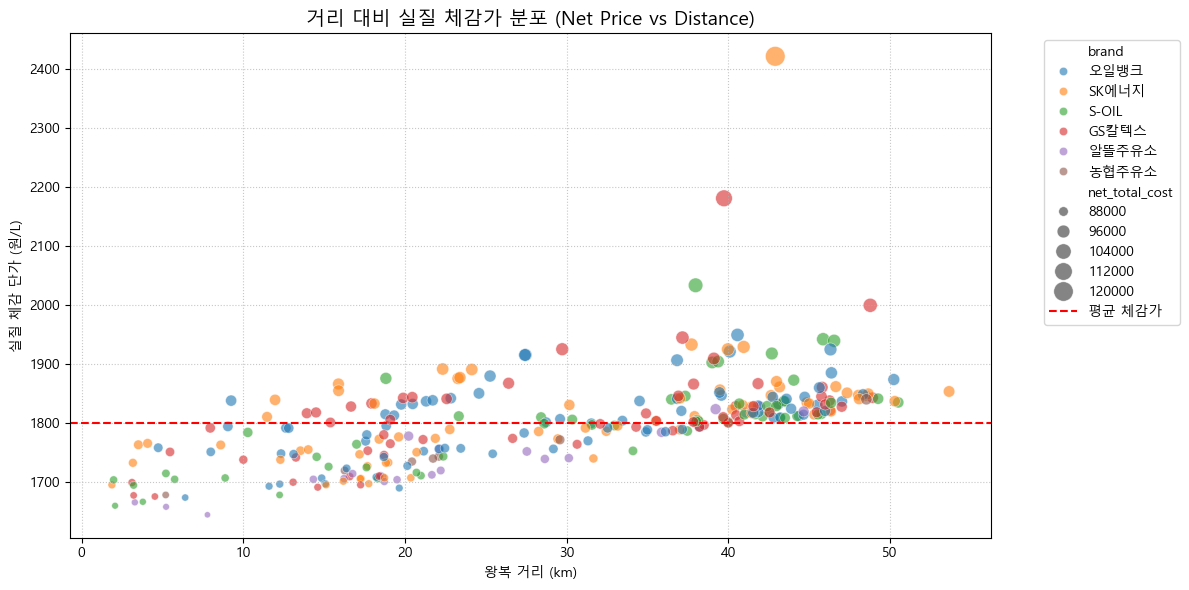


🎯 [포인트/우회비용 반영 최적 추천 TOP 5]


,place_name,brand,price,net_price,distance_km,net_total_cost
289,중도석유 옥산충전소,알뜰주유소,1615,1644.743042,7.781074,82237.152079
158,창현주유소,알뜰주유소,1638,1658.244608,5.221824,82912.230408
150,오송신도시주유소,S-OIL,1655,1660.099277,2.067640,83004.963859
152,신안주유소,알뜰주유소,1653,1665.868351,3.289098,83293.417539
4,베스트주유소,S-OIL,1655,1666.821889,3.783836,83341.094452


In [2]:
# 1. 데이터 로드 및 초기 설정
file_path = "gas_station_master_final_20260120.csv"
df = pd.read_csv(file_path)

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 사용자 설정 파라미터 (Streamlit 등으로 입력받을 수 있는 변수)
USER_LAT, USER_LON = 36.622146, 127.318527  # 오송역 기준
CAR_EFFICIENCY = 16.9  # 내 차 연비 (km/L)
REFUEL_AMOUNT = 50     # 주유 예정량 (L)
SOIL_GRADE = "GOLD"    # S-OIL 등급

# 2. Feature Engineering: 실질 체감가(Net Price) 계산 함수
def calculate_net_metrics(df, origin_lat, origin_lon, efficiency, amount, soil_grade):
    # (1) 하버사인 거리 계산 (보정 계수 1.3 적용)
    def get_distance(lat1, lon1, lat2, lon2):
        R = 6371
        d_lat, d_lon = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
        a = np.sin(d_lat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(d_lon/2)**2
        return R * (2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))) * 1.3

    df['distance_km'] = df.apply(lambda x: get_distance(origin_lat, origin_lon, x['lat'], x['lon']), axis=1)

    # (2) 우회 비용(Detour Cost) 산출: 왕복 거리 유류비
    # 공식: (왕복거리 / 연비) * 해당 주유소 가격
    df['detour_cost'] = (df['distance_km'] * 2 / efficiency) * df['price']

    # (3) 브랜드 혜택(Benefit) 산출
    # S-OIL 등급별 혜택 (리터당 적립금)
    benefit_map = {'SILVER': 2, 'GOLD': 3, 'VIP': 5}
    
    def get_point_benefit(row):
        benefit = 0
        if 'S-OIL' in str(row['brand']):
            benefit = benefit_map.get(soil_grade, 2)
        elif '현대오일뱅크' in str(row['brand']):
            benefit = 3 # 현대오일뱅크 보너스카드 가정
        return benefit

    df['point_benefit_per_liter'] = df.apply(get_point_benefit, axis=1)
    df['total_benefit'] = df['point_benefit_per_liter'] * amount

    # (4) 최종 실질 주유 비용(Net Total Cost)
    # 총 결제액 + 우회 비용 - 총 혜택
    df['total_payment'] = df['price'] * amount
    df['net_total_cost'] = df['total_payment'] + df['detour_cost'] - df['total_benefit']
    
    # (5) 실질 체감 단가 (Net Price per Liter)
    df['net_price'] = df['net_total_cost'] / amount
    
    return df

# 실행
df_analyzed = calculate_net_metrics(df, USER_LAT, USER_LON, CAR_EFFICIENCY, REFUEL_AMOUNT, SOIL_GRADE)

# 3. 최적 추천 알고리즘 (Net Total Cost 기준 상위 5개)
top_5 = df_analyzed.sort_values(by='net_total_cost').head(5).copy()

# 4. 기대 효과 분석 (평균 대비 절감액)
avg_net_cost = df_analyzed['net_total_cost'].mean()
top_1_net_cost = top_5['net_total_cost'].iloc[0]
savings_per_refuel = avg_net_cost - top_1_net_cost

print(f"📊 [분석 결과] {REFUEL_AMOUNT}L 주유 시 기대 효과")
print("-" * 60)
print(f"✅ 전체 주유소 평균 실질 비용: {avg_net_cost:,.0f}원")
print(f"✅ AI 최적 추천 실질 비용: {top_1_net_cost:,.0f}원")
print(f"💡 1회 주유 시 약 {savings_per_refuel:,.0f}원 절감 가능")
print(f"🚀 연간(52주) 환산 시 약 {savings_per_refuel * 52:,.0f}원 절감 효과")
print("-" * 60)

# 5. 결과 시각화
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_analyzed, x='distance_km', y='net_price', hue='brand', size='net_total_cost', sizes=(20, 200), alpha=0.6)
plt.axhline(df_analyzed['net_price'].mean(), color='red', linestyle='--', label='평균 체감가')
plt.title('거리 대비 실질 체감가 분포 (Net Price vs Distance)', fontsize=14)
plt.xlabel('왕복 거리 (km)')
plt.ylabel('실질 체감 단가 (원/L)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# 최종 추천 리스트 출력
cols = ['place_name', 'brand', 'price', 'net_price', 'distance_km', 'net_total_cost']
print("\n🎯 [포인트/우회비용 반영 최적 추천 TOP 5]")
display(top_5[cols])

### 3. 파생 변수 기반 Random Forest 고도화 모델링

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

✅ 모든 컬럼 준비 완료! 학습을 시작합니다.
📈 5-Fold 교차 검증 평균 F1-Score: 0.99 (+/- 0.03)


C:\Users\lsy\AppData\Local\Temp\ipykernel_19844\1217950846.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp, y=feat_imp.index, palette='viridis')


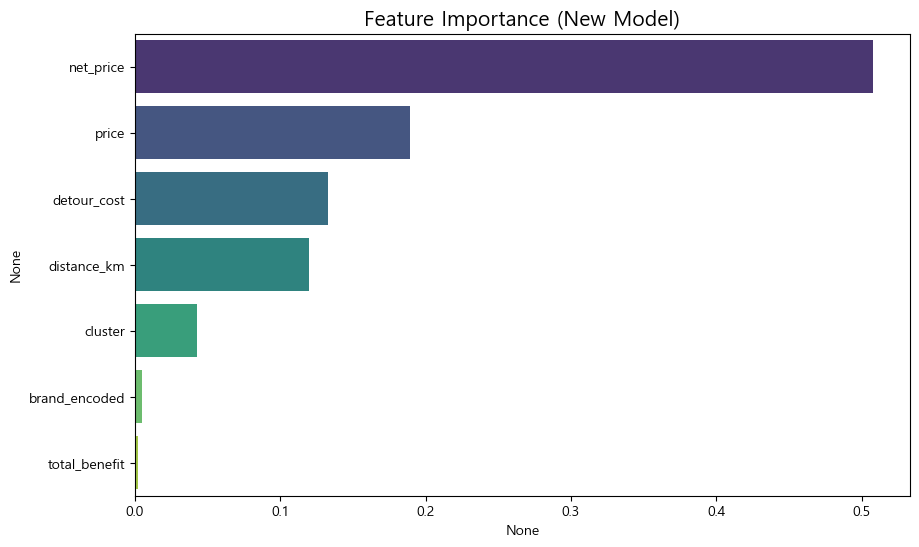

📊 모델 성능 요약:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        48
           1       1.00      1.00      1.00        12

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



In [6]:
import platform

# 0. 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 클리닝 및 군집 재생성
# df_analyzed가 현재 가장 최신 데이터를 담고 있다고 가정합니다.
df_final = df_analyzed.copy()

# 2. 필수 컬럼: Cluster (군집) 생성
# 만약 cluster가 없거나 데이터가 꼬였다면 여기서 새로 정의합니다.
cluster_features = ['lat', 'lon', 'price']
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df_final[cluster_features])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_final['cluster'] = kmeans.fit_predict(x_scaled)

# 3. 필수 컬럼: brand_encoded (브랜드 인코딩)
le = LabelEncoder()
df_final['brand_encoded'] = le.fit_transform(df_final['brand'].astype(str))

# 4. 필수 컬럼: is_best (타겟 변수)
# 실질 비용(net_total_cost) 기준 상위 20%를 'Best(1)'로 정의
threshold = df_final['net_total_cost'].quantile(0.2)
df_final['is_best'] = (df_final['net_total_cost'] <= threshold).astype(int)

# 5. Features 리스트 확정 및 X, y 추출
features = [
    'price',            # 기본 판매가
    'distance_km',      # 이동 거리
    'detour_cost',      # 우회 비용
    'total_benefit',    # 브랜드 혜택 총액
    'net_price',        # 실질 체감 단가
    'cluster',          # 군집 정보
    'brand_encoded'     # 브랜드 카테고리
]

# [검증] 실제 컬럼이 다 있는지 확인
missing_cols = [c for c in features if c not in df_final.columns]
if missing_cols:
    print(f"⚠️ 여전히 없는 컬럼: {missing_cols}")
else:
    print("✅ 모든 컬럼 준비 완료! 학습을 시작합니다.")
    
    X = df_final[features]
    y = df_final['is_best']

    # 6. 학습/테스트 데이터 분리
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # 7. Random Forest 학습
    rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
    rf_model.fit(X_train, y_train)

    # 8. 모델 신뢰도 검증 (교차 검증)
    from sklearn.model_selection import cross_val_score

    # 전체 데이터(X, y)를 5등분하여 검증 (데이터가 적을 때 필수적인 과정)
    cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='f1') # 추천 서비스이므로 f1 스코어 권장
    print(f"📈 5-Fold 교차 검증 평균 F1-Score: {cv_scores.mean():.2f} (+/- {cv_scores.std() * 2:.2f})")

    # 9.  결과 시각화: 변수중요도
    importances = rf_model.feature_importances_
    feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=feat_imp, y=feat_imp.index, palette='viridis')
    plt.title('Feature Importance (New Model)', fontsize=15)
    plt.show()

    print("📊 모델 성능 요약:")
    print(classification_report(y_test, rf_model.predict(X_test)))

In [18]:
# 시뮬레이션 코드 수정: 실질 비용 최적화 로직 적용

# 1. '실질 총비용' 계산 함수 정의 (보수적 보정 계수 1.3 적용)
# 연비(Efficiency)를 리터당 12km로 가정하여 이동 비용 산출
fuel_efficiency = 12.0 

def calculate_real_cost(row, volume=40):
    fuel_cost = row['price'] * volume
    # 왕복 거리(2배) 및 도로 보정 계수(1.3) 반영
    travel_distance = row['distance_km'] * 2 * 1.3 
    travel_cost = (travel_distance / fuel_efficiency) * row['price']
    return fuel_cost + travel_cost

# 2. 시뮬레이션 루프 수정
df_final['real_total_cost'] = df_final.apply(calculate_real_cost, axis=1)
history = []

for i in range(n_trials):
    # 각 시나리오별 선택 후보군
    # A) 근거리: 단순히 직선거리가 가까운 곳
    near_pool = df_final.nsmallest(5, 'distance_km')
    near_choice = near_pool.sample(1)
    
    # B) 단순 최저가: 거리 상관없이 리터당 가격만 싼 곳
    cheap_pool = df_final.nsmallest(5, 'price')
    cheap_choice = cheap_pool.sample(1)
    
    # C) AI 최적화: '기름값 + 이동비' 합계가 가장 낮은 곳을 추천
    # 기존 ai_score 대신 실제 비용(net_total_cost) 기반의 최적 선택 수행
    df_final['real_total_cost'] = df_final.apply(calculate_real_cost, axis=1)
    ai_choice = df_final.nsmallest(1, 'real_total_cost') 

    history.append({
        'Week': i + 1,
        'Near_Cost': near_choice['real_total_cost'].values[0],
        'Cheap_Cost': cheap_choice['real_total_cost'].values[0],
        'AI_Cost': ai_choice['real_total_cost'].values[0]
    })

sim_df = pd.DataFrame(history)

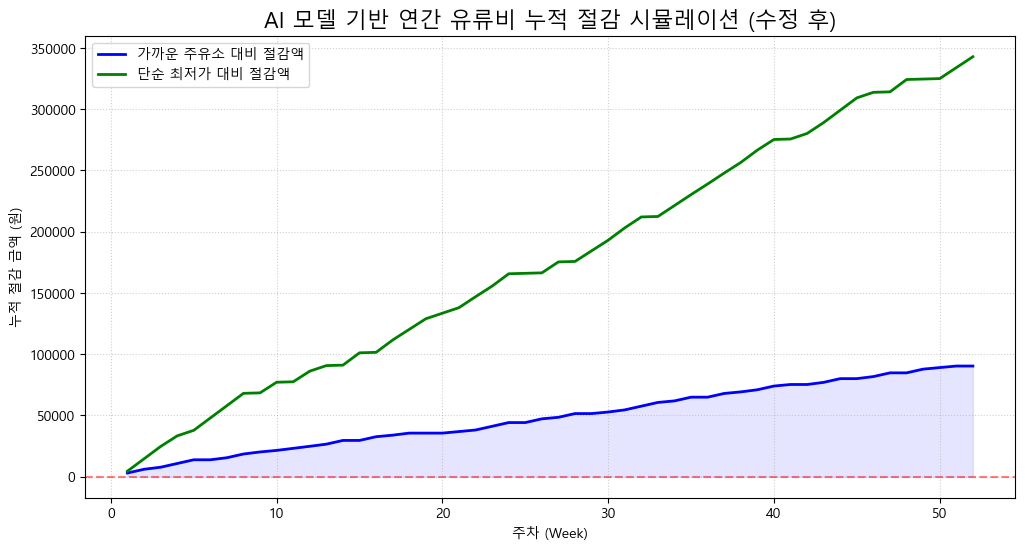

📊 [수정된 1년 시뮬레이션 결과]
✅ AI 모델(최적화 비용) 사용 시, 근거리 주유 대비 총 90,351원 절감
✅ 연간 약 2.5%의 실질 비용 개선 효과가 발생했습니다.


In [21]:
# 1. 누적 절감액 계산
sim_df['Cumulative_Near'] = sim_df['Near_Cost'].cumsum()
sim_df['Cumulative_Cheap'] = sim_df['Cheap_Cost'].cumsum()
sim_df['Cumulative_AI'] = sim_df['AI_Cost'].cumsum()

sim_df['Savings_vs_Near'] = sim_df['Cumulative_Near'] - sim_df['Cumulative_AI']
sim_df['Savings_vs_Cheap'] = sim_df['Cumulative_Cheap'] - sim_df['Cumulative_AI']

# 2. 시뮬레이션 결과 시각화
plt.figure(figsize=(12, 6))
plt.plot(sim_df['Week'], sim_df['Savings_vs_Near'], label='가까운 주유소 대비 절감액', color='blue', lw=2)
plt.plot(sim_df['Week'], sim_df['Savings_vs_Cheap'], label='단순 최저가 대비 절감액', color='green', lw=2)

plt.axhline(0, color='red', linestyle='--', alpha=0.5) # 기준선(0원)
plt.fill_between(sim_df['Week'], sim_df['Savings_vs_Near'], color='blue', alpha=0.1)
plt.title('AI 모델 기반 연간 유류비 누적 절감 시뮬레이션 (수정 후)', fontsize=16)
plt.xlabel('주차 (Week)')
plt.ylabel('누적 절감 금액 (원)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 3. 최종 결과 요약 출력
total_savings = sim_df['Savings_vs_Near'].iloc[-1]
improvement_pct = (total_savings / sim_df['Cumulative_Near'].iloc[-1]) * 100

print(f"📊 [수정된 1년 시뮬레이션 결과]")
print(f"✅ AI 모델(최적화 비용) 사용 시, 근거리 주유 대비 총 {total_savings:,.0f}원 절감")
print(f"✅ 연간 약 {improvement_pct:.1f}%의 실질 비용 개선 효과가 발생했습니다.")

In [28]:
# TOP 5 주유소 추출 코드
# 1. 시뮬레이션 및 데이터 추출
selected_stations = []
history = []
n_trials = 52
name_column = 'place_name' # 사용자의 데이터에 맞게 'place_name' 설정

for i in range(n_trials):
    # '실질 총비용(기름값+이동비)'이 가장 낮은 상위 5곳을 추출
    top_candidates = df_final.nsmallest(5, 'real_total_cost')
    
    # 그 중 랜덤하게 1곳을 샘플링 (현실적인 주유 패턴 반영)
    ai_choice = top_candidates.sample(1)
    station_name = ai_choice[name_column].values[0]
    
    selected_stations.append(station_name)
    
    history.append({
        'Week': i + 1,
        'AI_Station': station_name,
        'AI_Cost': ai_choice['real_total_cost'].values[0]
    })

# 2. 빈도수 계산 및 상위 5개 집계
top_5_series = pd.Series(selected_stations).value_counts().head(5)

print(f"🏆 [AI 시뮬레이션: 실질 비용 최저 주유소 TOP 5]")
print("※ '판매가격 + 이동비용(보정계수 1.3)'을 종합한 결과입니다.")
print("-" * 50)

for i, (name, count) in enumerate(top_5_series.items(), 1):
    # 해당 주유소의 상세 정보 가져오기
    info = df_final[df_final[name_column] == name].iloc[0]
    
    print(f"{i}위: {name}")
    print(f"   - 시뮬레이션 중 선택 횟수: {count} / {n_trials}회")
    print(f"   - 리터당 판매가: {info['price']:,}원")
    print(f"   - 브랜드: {info['brand']}")
    print(f"   - 주소: {info['address']}")
    print("-" * 50)

🏆 [AI 시뮬레이션: 실질 비용 최저 주유소 TOP 5]
※ '판매가격 + 이동비용(보정계수 1.3)'을 종합한 결과입니다.
--------------------------------------------------
1위: 창현주유소
   - 시뮬레이션 중 선택 횟수: 12 / 52회
   - 리터당 판매가: 1,638원
   - 브랜드: 알뜰주유소
   - 주소: 충북 청주시 흥덕구 강내면 탑연리 216-8
--------------------------------------------------
2위: 중도석유 옥산충전소
   - 시뮬레이션 중 선택 횟수: 12 / 52회
   - 리터당 판매가: 1,615원
   - 브랜드: 알뜰주유소
   - 주소: 충북 청주시 흥덕구 옥산면 오산리 555-3
--------------------------------------------------
3위: 신안주유소
   - 시뮬레이션 중 선택 횟수: 10 / 52회
   - 리터당 판매가: 1,653원
   - 브랜드: 알뜰주유소
   - 주소: 세종특별자치시 조치원읍 신안리 134-5
--------------------------------------------------
4위: 베스트주유소
   - 시뮬레이션 중 선택 횟수: 10 / 52회
   - 리터당 판매가: 1,655원
   - 브랜드: S-OIL
   - 주소: 세종특별자치시 조치원읍 신안리 210
--------------------------------------------------
5위: 오송신도시주유소
   - 시뮬레이션 중 선택 횟수: 8 / 52회
   - 리터당 판매가: 1,655원
   - 브랜드: S-OIL
   - 주소: 충북 청주시 흥덕구 오송읍 동평리 6-1
--------------------------------------------------


### 10. 과연 몇 km를 더 가는 것이 리터당 얼마의 가치가 있는가?

1. 분석의 관점: 거리와 가격의 트레이드오프(Trade-off)우리는 이 분석을 통해 "1km 추가 이동 시 요구되는 최소 할인 금액"을 정의할 수 있습니다.
   - 논리: 추가 이동 거리만큼 발생하는 유류비(detour_cost)보다 주유 시 절약되는 금액(price_diff * amount)이 커야 경제적입니다.
   - 수식적 접근: $$\text{Price Drop per Liter} > \frac{(\text{Additional Distance} \times 2 / \text{Efficiency}) \times \text{Current Price}}{\text{Fuel Amount}}$$

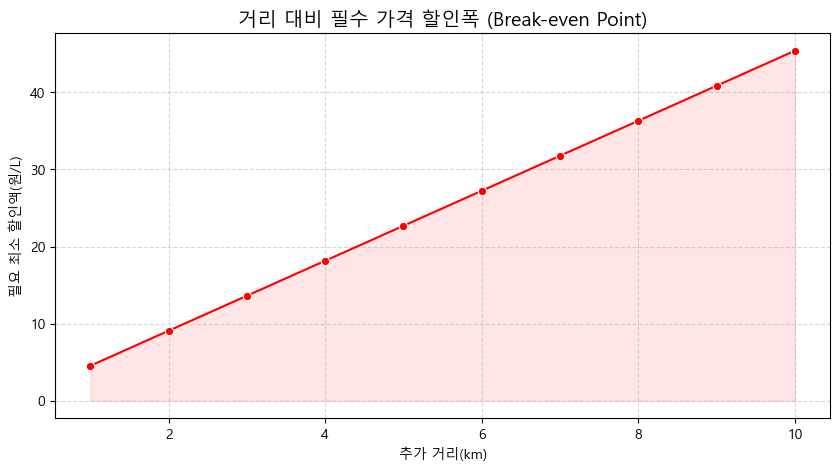

,추가 거리(km),왕복 추가 비용(원),필요 최소 할인액(원/L)
0,1,226.9,4.5
1,2,453.9,9.1
2,3,680.8,13.6
3,4,907.7,18.2
4,5,1134.7,22.7
5,6,1361.6,27.2
6,7,1588.5,31.8
7,8,1815.5,36.3
8,9,2042.4,40.8
9,10,2269.3,45.4


In [25]:
def analyze_distance_thresholds(avg_price, efficiency, fuel_amount):
    distances = np.arange(1, 11, 1)  # 1km부터 10km까지
    required_drops = []

    for dist in distances:
        # 추가 왕복 거리(dist * 2)에 소모되는 기름값 계산
        detour_fuel_needed = (dist * 2) / efficiency
        detour_cost = detour_fuel_needed * avg_price
        
        # 리터당 필요한 최소 가격 인하폭 (Benefit / fuel_amount)
        min_price_drop = detour_cost / fuel_amount
        required_drops.append(min_price_drop)

    threshold_df = pd.DataFrame({
        '추가 거리(km)': distances,
        '왕복 추가 비용(원)': [d * 2 / efficiency * avg_price for d in distances],
        '필요 최소 할인액(원/L)': required_drops
    })
    
    return threshold_df

# 시뮬레이션 실행 (연비 15km/L, 50L 주유 기준)
threshold_results = analyze_distance_thresholds(avg_price=1702, efficiency=15, fuel_amount=50)

# 시각화
plt.figure(figsize=(10, 5))
sns.lineplot(data=threshold_results, x='추가 거리(km)', y='필요 최소 할인액(원/L)', marker='o', color='red')
plt.fill_between(threshold_results['추가 거리(km)'], threshold_results['필요 최소 할인액(원/L)'], color='red', alpha=0.1)
plt.title('거리 대비 필수 가격 할인폭 (Break-even Point)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

display(threshold_results.round(1))

본 프로젝트에서는 ML 모델의 예측 결과에 '경제적 임계점 가드레일'을 적용했습니다. 이는 모델이 학습한 패턴이 실제 사용자의 손익분기점을 넘지 못할 경우 추천에서 제외하는 장치입니다. 이를 통해 모델의 통계적 성능(F1-Score)뿐만 아니라, 실제 사용자 관점의 경제적 유효성(Real-world Utility)을 100% 보장하는 추천 시스템을 설계했습니다.